# Run collective variable umbrella sampling

In [25]:
import numpy as np
from Bio.PDB import PDBParser
import pandas as pd
import mdtraj as md
import nglview as nv
import seaborn as sns
import matplotlib.pyplot as plt

## Locate interface atoms between protein partners (NOT with stabilizer)
Model system to run production MD: _Minimized, heated and equilibrated_ `2o98`

In [9]:
def process_pdb_as_txt_dist_tuple_dict(file, va1, va2, va3, va4, dd=16.0):
    a, xa, b, xb = [], [], [], []
    distance_dict = {}  # Initialize the dictionary to store distances

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and not fields[2].startswith("H") and fields[2] not in ["C", "N", "O"]:
                if va1 <= int(fields[4]) <= va2:
                    a.append(int(fields[1]))
                    xa.extend([float(fields[i]) for i in range(5, 8)])
                elif va3 <= int(fields[4]) <= va4:
                    b.append(int(fields[1]))
                    xb.extend([float(fields[i]) for i in range(5, 8)])

    xa, xb = np.array(xa).reshape(-1, 3), np.array(xb).reshape(-1, 3)
    ima, imb = np.zeros(len(a), dtype=bool), np.zeros(len(b), dtype=bool)

    for n in range(len(a)):
        for j in range(len(b)):
            d = np.sum((xa[n] - xb[j]) ** 2)
            if d < dd:
                ima[n] = True
                imb[j] = True
                # Add the distance to the dictionary, using the atom serial number as the key
                if a[n] in distance_dict:
                    distance_dict[a[n]].append((b[j], d))  # Store the atom and distance as a tuple
                else:
                    distance_dict[a[n]] = [(b[j], d)]  # Store the atom and distance as a tuple

    max_count = np.sum(ima) + np.sum(imb)
    output_a = np.array(a)[ima]
    output_b = np.array(b)[imb]
    output_xa = xa[ima]
    output_xb = xb[imb]

    # Return the atom serial numbers (2), total count, coordinates (2), and the distance dictionary
    return output_a, output_b, max_count, output_xa, output_xb, distance_dict

### Get interface atom indices from solvated PDB
AFTER building topology $\because$ 
1. model missing residues `mod10.4`
2. add H atoms `tleap` 

BUT BEFORE minimization step

NOT easy to justify using equilibrated PDB to get interface atoms\
$\because$ it is just one frame out of all equilibration\
i.e., interface atoms may have highly variable coordinates during equilibration\
$\rightarrow$ very different "interface" atoms considered 

In [205]:
path_2o98 = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/amber_o98_FSC_cubic_ion.pdb'

In [206]:
(int_atom_c1_nonHCNO_2o98, int_atom_c2_nonHCNO_2o98, 
 num_int_atom_nonHCNO_2o98, 
 xyz_c1_nonHCNO_2o98, xyz_c2_nonHCNO_2o98, 
 sqdist_tuple_dict_nonHCNO_2o98) = process_pdb_as_txt_dist_tuple_dict(
    path_2o98, 1, 242, 243, 294, dd=16.0)

In [207]:
int_atom_c1_nonHCNO_2o98

array([ 870,  879,  979,  982,  988,  990,  994, 1046, 1048, 1051, 1054,
       1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169,
       1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922,
       3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667,
       3678, 3746])

In [209]:
int_atom_c2_nonHCNO_2o98

array([4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355,
       4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619,
       4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665,
       4666, 4673, 4675, 4682, 4688])

In [210]:
num_int_atom_nonHCNO_2o98

84

In [213]:
84 * 3

252

In [211]:
xyz_c1_nonHCNO_2o98

array([[  4.257,  -2.851,  -2.134],
       [  1.645,  -1.376,  -1.816],
       [  0.079,  -8.641,  -7.187],
       [  1.29 ,  -9.189,  -6.429],
       [  0.093,  -9.876,  -4.425],
       [ -0.218, -10.689,  -3.373],
       [ -1.01 , -10.226,  -2.362],
       [ -5.635, -11.299, -10.064],
       [ -5.861, -10.445,  -8.804],
       [ -5.598,  -8.952,  -8.974],
       [ -5.467,  -8.241,  -7.627],
       [ -4.286,  -8.834,  -6.935],
       [ -4.008,  -8.51 ,  -5.639],
       [ -4.809,  -7.631,  -4.968],
       [ -2.93 ,  -9.065,  -5.012],
       [ -8.428,  -7.884, -14.385],
       [ -9.531,  -7.433, -13.428],
       [-11.075, -13.437, -12.492],
       [-11.405, -12.009, -12.034],
       [-10.936, -11.806, -10.709],
       [-11.506, -13.389, -16.246],
       [-14.684, -17.606, -11.543],
       [-15.781, -14.638, -16.131],
       [  5.031,  -4.705,   5.38 ],
       [  1.678, -10.678,   1.396],
       [  0.636, -10.963,   0.561],
       [  2.326,  -9.481,   1.292],
       [ -1.985,  -6.088,   

In [212]:
xyz_c2_nonHCNO_2o98

array([[ -9.323,   5.283,   5.336],
       [-10.076,   4.728,   6.542],
       [ -4.489,   6.156,   2.531],
       [ -9.099,   1.189,   2.532],
       [-11.706,   0.224,   2.777],
       [ -0.487,   3.574,   1.205],
       [ -1.004,   4.839,   1.039],
       [ -2.629,  -5.42 ,  -3.677],
       [ -0.701,  -7.065,  -3.81 ],
       [ -7.086,  -4.966,  -7.409],
       [ -7.839,  -5.899,  -8.371],
       [ -5.607,  -5.329,  -7.198],
       [-11.253,  -5.03 , -11.146],
       [-11.691,  -7.357, -15.441],
       [-13.946, -11.131, -13.224],
       [-14.1  , -11.955, -14.5  ],
       [-16.579, -14.915,  -9.421],
       [-17.506, -15.475, -10.068],
       [-15.978, -15.446,  -8.45 ],
       [ -8.519, -11.149,  -7.463],
       [ -8.217,  -7.632,  -4.489],
       [ -8.486,  -6.528,  -4.018],
       [ -7.676,  -7.785,  -5.728],
       [ -7.695, -10.685,   3.058],
       [ -5.63 ,  -5.363,   2.626],
       [ -6.06 ,  -4.094,   3.383],
       [ -7.312,  -3.565,   2.771],
       [ -8.542,  -4.014,   

In [208]:
sqdist_tuple_dict_nonHCNO_2o98

{870: [(4688, 15.044458999999996)],
 879: [(4688, 13.966574000000001)],
 979: [(4297, 14.496305)],
 982: [(4297, 15.334617999999999)],
 988: [(4297, 8.910381999999995)],
 990: [(4297, 13.557633999999997)],
 994: [(4297, 12.184106000000003), (4666, 15.706853000000004)],
 1046: [(4585, 15.105157000000002)],
 1048: [(4585, 9.358861000000001)],
 1051: [(4355, 14.706499), (4585, 15.642170999999998)],
 1054: [(4353, 13.394309999999999),
  (4355, 11.664884000000002),
  (4359, 8.683385),
  (4620, 8.693818000000002)],
 1057: [(4359, 14.099235000000002), (4620, 14.049350000000002)],
 1059: [(4288, 15.299185),
  (4359, 15.106043000000001),
  (4620, 13.987770000000001)],
 1060: [(4288, 11.307602000000003),
  (4359, 10.908908000000004),
  (4618, 11.843906),
  (4619, 15.639438000000006),
  (4620, 8.821005000000001)],
 1063: [(4288, 15.158850999999995), (4297, 10.413244999999996)],
 1078: [(4506, 12.040034000000002)],
 1081: [(4413, 13.947216999999995), (4506, 8.723545)],
 1119: [(4534, 14.0961009999

#### Get a continuous list of indices ~~and coordinates~~
For `colv.in` file

##### Atom indices (`cv_ni`)

In [220]:
# Join the arrays
joined_atom_array = np.concatenate((int_atom_c1_nonHCNO_2o98, int_atom_c2_nonHCNO_2o98))

# Flatten the array
flattened_atom_array = joined_atom_array.ravel()

# Convert the array to a string with commas as separators
flattened_atom_str = ', '.join(map(str, flattened_atom_array))

print(flattened_atom_str)

870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746, 4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688


##### Get atom indices that can be input to VMD `atomselect` (0-index)

In [1]:
import numpy as np

In [11]:
atom_index_list = [870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746, 4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688]
atom_index_array = np.array(atom_index_list)

In [4]:
vmd_atom_index_array = atom_index_array - 1
print(vmd_atom_index_array)

[ 869  878  978  981  987  989  993 1045 1047 1050 1053 1056 1058 1059
 1062 1077 1080 1118 1120 1123 1129 1168 1182 2054 2171 2172 2175 2860
 2874 2875 2915 2917 2921 3000 3532 3555 3582 3585 3588 3590 3602 3608
 3661 3666 3677 3745 4134 4137 4181 4204 4210 4259 4260 4287 4296 4352
 4354 4358 4412 4505 4533 4536 4552 4553 4554 4584 4617 4618 4619 4631
 4637 4639 4642 4643 4645 4658 4660 4663 4664 4665 4672 4674 4681 4687]


In [7]:
vmd_atom_index_array_string = np.array2string(vmd_atom_index_array)
print(vmd_atom_index_array_string)

[ 869  878  978  981  987  989  993 1045 1047 1050 1053 1056 1058 1059
 1062 1077 1080 1118 1120 1123 1129 1168 1182 2054 2171 2172 2175 2860
 2874 2875 2915 2917 2921 3000 3532 3555 3582 3585 3588 3590 3602 3608
 3661 3666 3677 3745 4134 4137 4181 4204 4210 4259 4260 4287 4296 4352
 4354 4358 4412 4505 4533 4536 4552 4553 4554 4584 4617 4618 4619 4631
 4637 4639 4642 4643 4645 4658 4660 4663 4664 4665 4672 4674 4681 4687]


##### (WRONG) Atom coordinates (`cv_r`)
Use equilibrated coordinates

In [219]:
joined_xyz_array = np.concatenate((xyz_c1_nonHCNO_2o98, xyz_c2_nonHCNO_2o98))
flattened_xyz_array = joined_xyz_array.ravel()
flattened_xyz_str = ', '.join(map(str, flattened_xyz_array))
print(flattened_xyz_str)

4.257, -2.851, -2.134, 1.645, -1.376, -1.816, 0.079, -8.641, -7.187, 1.29, -9.189, -6.429, 0.093, -9.876, -4.425, -0.218, -10.689, -3.373, -1.01, -10.226, -2.362, -5.635, -11.299, -10.064, -5.861, -10.445, -8.804, -5.598, -8.952, -8.974, -5.467, -8.241, -7.627, -4.286, -8.834, -6.935, -4.008, -8.51, -5.639, -4.809, -7.631, -4.968, -2.93, -9.065, -5.012, -8.428, -7.884, -14.385, -9.531, -7.433, -13.428, -11.075, -13.437, -12.492, -11.405, -12.009, -12.034, -10.936, -11.806, -10.709, -11.506, -13.389, -16.246, -14.684, -17.606, -11.543, -15.781, -14.638, -16.131, 5.031, -4.705, 5.38, 1.678, -10.678, 1.396, 0.636, -10.963, 0.561, 2.326, -9.481, 1.292, -1.985, -6.088, 5.923, 2.813, -6.456, 5.367, 1.046, -7.304, 4.219, -2.71, -10.768, 4.884, -3.138, -11.186, 3.465, -3.253, -9.402, 5.336, -3.286, -12.53, 0.624, -2.312, 4.24, 4.498, 0.133, -0.58, 7.602, -7.839, 2.401, 8.786, -9.179, 2.361, 8.05, -10.299, 2.454, 9.078, -10.381, 3.609, 9.791, -5.354, -0.794, 5.396, -4.108, -1.014, 4.524, -10.51

NOTE: these coordinates are from the "ground" state PDB crystals\
which are NOT the same as the equilibrated state

### Get coordinates of interface atoms from equilibrated PDB

##### Dry PDB files in `cpptraj`

The output PDB from:
```sh
cpptraj -p amber_o98_dry.parm7 -y amber_o98_equil_dry.rst7 
```
```cpptraj
CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 07/03/24 17:00:26
| Available memory: 515.482 MB

        Reading 'amber_o98_dry.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading 'amber_o98_equil_dry.rst7' as Amber Restart
        Loading previous history from log 'cpptraj.log'
> trajout amber_o98_equil_dry_rst7.pdb PDB
  [trajout amber_o98_equil_dry_rst7.pdb PDB]
        Writing 'amber_o98_equil_dry_rst7.pdb' as PDB
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_o98_dry.parm7, 4688 atoms, 294 res, box: Orthorhombic, 2 mol

INPUT TRAJECTORIES (1 total):
 0: 'amber_o98_equil_dry.rst7' is an AMBER restart file with velocity info, Parm amber_o98_dry.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_o98_equil_dry_rst7.pdb' (1 frames) is a PDB file

BEGIN TRAJECTORY PROCESSING:
Warning: No PDB space group specified.
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_o98_equil_dry_rst7.pdb (coordinates, velocities, time, box)
----- amber_o98_equil_dry.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 21.9727 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.26%)
TIME:           Trajectory Process : 0.0455 s ( 99.65%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0000 s (  0.00%)
TIME:   Run Total 0.0457 s
---------- RUN END ---------------------------------------------------
> quit
  [quit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```
and
```sh
cpptraj -p amber_o98_dry.parm7 -y amber_o98_postEquil_dry.rst7 -ya 'lastframe' -x amber_o98_postEquil_lastFrame_dry.pdb
```
```cpptraj
CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 07/04/24 10:42:25
| Available memory: 428.241 MB

        Reading 'amber_o98_dry.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Arguments for 1 input trajectories:
          amber_o98_postEquil_dry.rst7 lastframe
        Reading 'amber_o98_postEquil_dry.rst7' as Amber Restart
        Writing 'amber_o98_postEquil_lastFrame_dry.pdb' as PDB
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_o98_dry.parm7, 4688 atoms, 294 res, box: Orthorhombic, 2 mol

INPUT TRAJECTORIES (1 total):
 0: 'amber_o98_postEquil_dry.rst7' is an AMBER restart file with velocity info, Parm amber_o98_dry.parm7 (Orthorhombic box) (reading 1 of 1)
  Coordinate processing will occur on 1 frames.

OUTPUT TRAJECTORIES (1 total):
  'amber_o98_postEquil_lastFrame_dry.pdb' (1 frames) is a PDB file

BEGIN TRAJECTORY PROCESSING:
Warning: No PDB space group specified.
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  amber_o98_postEquil_lastFrame_dry.pdb (coordinates, velocities, time, box)
----- amber_o98_postEquil_dry.rst7 (1-1, 1) -----
100% Complete.

Read 1 frames and processed 1 frames.
TIME: Avg. throughput= 116.1036 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0000 s (  0.16%)
TIME:           Trajectory Process : 0.0086 s ( 99.65%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0000 s (  0.00%)
TIME:   Run Total 0.0086 s
---------- RUN END ---------------------------------------------------
TIME: Total execution time: 0.0208 seconds.
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```
are the same?\
i.e., `parmout` generates PDB from last frame by default?

NOTE: names of the input RESTART files have changed between runs, but they are all post-equilibration files (i.e., `9md.rst7`)

#### Get interface atoms' coordinates from equilibrated PDB file
NOTE: atomic coordinates used for FSC$^{+}$ runs seems incorrect...

In [5]:
path2_o98_9md_dry = 'B2/prod_colv_receptor_interface_ligand/amber_o98_9md_dry.pdb'
path2_o98_FSC_9md_dry = 'B2/prod_colv_receptor_interface_ligand_FSC/amber_o98_FSC_9md_dry.pdb'

Previous run used:

In [7]:
path2_2o98_preMin_dry = 'B2/trial7_cubic_temp_barostat/amber_o98_preMin_dry.pdb'
path2_2o98_postEquil_dry = 'B2/trial7_cubic_temp_barostat/amber_o98_postEquil_lastFrame_dry.pdb'

##### (REDUNDANT) Get atomic coordinates from PDB file as dictionary

In [1]:
def get_coordinates_dict(file, atom_indices):
    coordinates = {}

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and int(fields[1]) in atom_indices:
                # Store the coordinates as a tuple in the dictionary, using the atom index as the key
                coordinates[int(fields[1])] = tuple(float(fields[i]) for i in range(5, 8))

    return coordinates

Pre-minimization (solvated crystal structure)

In [18]:
interface_atom_coords_preMin_dict = get_coordinates_dict(path2_2o98_preMin_dry, interface_atom_index_list)
interface_atom_coords_preMin_dict

{870: (52.236, 43.754, 42.628),
 879: (49.624, 45.229, 42.946),
 979: (48.058, 37.964, 37.575),
 982: (49.269, 37.416, 38.333),
 988: (48.072, 36.729, 40.337),
 990: (47.761, 35.916, 41.389),
 994: (46.969, 36.379, 42.4),
 1046: (42.344, 35.306, 34.698),
 1048: (42.118, 36.16, 35.958),
 1051: (42.381, 37.653, 35.788),
 1054: (42.512, 38.364, 37.135),
 1057: (43.693, 37.771, 37.827),
 1059: (43.971, 38.095, 39.123),
 1060: (43.17, 38.974, 39.794),
 1063: (45.049, 37.54, 39.75),
 1078: (39.551, 38.721, 30.377),
 1081: (38.448, 39.172, 31.334),
 1119: (36.904, 33.168, 32.27),
 1121: (36.574, 34.596, 32.728),
 1124: (37.043, 34.799, 34.053),
 1130: (36.473, 33.216, 28.516),
 1169: (33.295, 28.999, 33.219),
 1183: (32.198, 31.967, 28.631),
 2055: (53.01, 41.9, 50.142),
 2172: (49.657, 35.927, 46.158),
 2173: (48.615, 35.642, 45.323),
 2176: (50.305, 37.124, 46.054),
 2861: (45.994, 40.517, 50.685),
 2875: (50.792, 40.149, 50.129),
 2876: (49.025, 39.301, 48.981),
 2916: (45.269, 35.837, 49.

After minimization, heating & equilibration

In [17]:
interface_atom_coords_postEquil_dict = get_coordinates_dict(path2_2o98_postEquil_dry, interface_atom_index_list)
interface_atom_coords_postEquil_dict

{870: (49.904, 42.963, 39.278),
 879: (49.225, 40.077, 41.842),
 979: (43.985, 37.076, 33.484),
 982: (45.309, 36.326, 33.914),
 988: (45.035, 36.553, 36.406),
 990: (44.522, 35.483, 36.916),
 994: (43.822, 35.613, 38.004),
 1046: (37.778, 34.782, 30.999),
 1048: (37.73, 35.839, 32.182),
 1051: (38.477, 35.193, 33.339),
 1054: (38.898, 36.228, 34.424),
 1057: (39.66, 35.592, 35.555),
 1059: (39.79, 36.081, 36.753),
 1060: (39.112, 37.097, 37.227),
 1063: (40.516, 35.383, 37.536),
 1078: (36.005, 38.827, 28.765),
 1081: (36.679, 40.206, 28.649),
 1119: (32.436, 32.862, 28.648),
 1121: (32.338, 34.341, 28.964),
 1124: (32.946, 34.699, 30.191),
 1130: (31.659, 32.828, 24.926),
 1169: (30.755, 28.729, 29.657),
 1183: (27.153, 30.862, 24.535),
 2055: (49.676, 39.965, 45.757),
 2172: (45.821, 34.191, 43.119),
 2173: (44.836, 34.294, 42.294),
 2176: (46.545, 35.23, 43.411),
 2861: (41.57, 40.037, 49.086),
 2875: (45.479, 38.143, 46.595),
 2876: (47.462, 37.736, 45.804),
 2916: (41.747, 33.359

i.e., they are very different!

##### Dictionary is helpful, but list is easier to specify in `colv_.in`

In [1]:
def get_coordinates_list(file, atom_indices):
    coordinates = [] 

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM" and int(fields[1]) in atom_indices:
                # Append the coordinates directly to the list
                coordinates.extend(float(fields[i]) for i in range(5, 8))

    return coordinates

##### Restrain both receptor and ligand interface atoms

In [4]:
interface_atom_index_list = [870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746, 4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688]
print(interface_atom_index_list)

[870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746, 4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688]


In [10]:
len(interface_atom_index_list)

84

FSC$^{-}$

In [6]:
interface_atom_coordinates_o98_9md_list = get_coordinates_list(path2_o98_9md_dry, interface_atom_index_list)
print(interface_atom_coordinates_o98_9md_list)

[49.904, 42.963, 39.278, 49.225, 40.077, 41.842, 43.985, 37.076, 33.484, 45.309, 36.326, 33.914, 45.035, 36.553, 36.406, 44.522, 35.483, 36.916, 43.822, 35.613, 38.004, 37.778, 34.782, 30.999, 37.73, 35.839, 32.182, 38.477, 35.193, 33.339, 38.898, 36.228, 34.424, 39.66, 35.592, 35.555, 39.79, 36.081, 36.753, 39.112, 37.097, 37.227, 40.516, 35.383, 37.536, 36.005, 38.827, 28.765, 36.679, 40.206, 28.649, 32.436, 32.862, 28.648, 32.338, 34.341, 28.964, 32.946, 34.699, 30.191, 31.659, 32.828, 24.926, 30.755, 28.729, 29.657, 27.153, 30.862, 24.535, 49.676, 39.965, 45.757, 45.821, 34.191, 43.119, 44.836, 34.294, 42.294, 46.545, 35.23, 43.411, 41.57, 40.037, 49.086, 45.479, 38.143, 46.595, 47.462, 37.736, 45.804, 41.747, 33.359, 46.046, 41.699, 33.147, 44.504, 40.747, 34.479, 46.331, 39.46, 28.903, 38.439, 39.264, 48.721, 47.224, 45.661, 45.302, 49.857, 36.072, 46.396, 51.604, 35.89, 47.207, 52.896, 35.703, 48.663, 52.693, 35.577, 49.335, 53.783, 38.783, 43.777, 46.954, 40.23, 44.11, 46.521, 

In [11]:
len(interface_atom_coordinates_o98_9md_list)

252

FSC$^{+}$

In [8]:
interface_atom_coordinates_o98_FSC_9md_list = get_coordinates_list(path2_o98_FSC_9md_dry, interface_atom_index_list)
print(interface_atom_coordinates_o98_FSC_9md_list)

[49.029, 41.379, 38.653, 46.365, 41.24, 39.781, 46.151, 34.122, 34.097, 45.678, 33.286, 35.282, 43.66, 33.047, 36.725, 43.646, 32.012, 37.556, 43.332, 32.226, 38.772, 39.882, 31.25, 31.206, 39.757, 32.085, 32.406, 40.419, 31.453, 33.663, 40.236, 32.237, 34.949, 40.485, 31.363, 36.176, 40.022, 31.583, 37.393, 39.547, 32.798, 37.642, 40.113, 30.762, 38.352, 39.28, 35.177, 27.614, 37.839, 35.734, 27.511, 34.897, 30.364, 28.06, 35.108, 31.883, 28.313, 35.365, 32.148, 29.677, 34.991, 29.263, 24.248, 30.313, 26.58, 28.423, 29.92, 28.435, 23.653, 47.991, 39.195, 46.237, 44.865, 33.689, 43.786, 43.897, 33.805, 42.953, 45.7, 34.67, 43.902, 40.86, 40.323, 46.875, 43.776, 37.924, 46.349, 45.709, 37.404, 45.598, 39.964, 33.386, 45.611, 39.808, 33.001, 44.118, 39.324, 34.782, 45.889, 37.551, 31.407, 40.65, 40.819, 49.715, 44.878, 43.992, 45.576, 49.754, 34.637, 46.904, 48.45, 33.302, 46.958, 47.7, 32.133, 46.74, 48.642, 31.511, 45.566, 48.57, 38.071, 43.827, 45.784, 37.14, 43.873, 44.628, 32.278, 4

In [12]:
len(interface_atom_coordinates_o98_FSC_9md_list)

252

Previous runs

In [23]:
interface_atom_coords_postEquil_list = get_coordinates_list(path2_2o98_postEquil_dry, interface_atom_index_list)
print(interface_atom_coords_postEquil_list)

[49.904, 42.963, 39.278, 49.225, 40.077, 41.842, 43.985, 37.076, 33.484, 45.309, 36.326, 33.914, 45.035, 36.553, 36.406, 44.522, 35.483, 36.916, 43.822, 35.613, 38.004, 37.778, 34.782, 30.999, 37.73, 35.839, 32.182, 38.477, 35.193, 33.339, 38.898, 36.228, 34.424, 39.66, 35.592, 35.555, 39.79, 36.081, 36.753, 39.112, 37.097, 37.227, 40.516, 35.383, 37.536, 36.005, 38.827, 28.765, 36.679, 40.206, 28.649, 32.436, 32.862, 28.648, 32.338, 34.341, 28.964, 32.946, 34.699, 30.191, 31.659, 32.828, 24.926, 30.755, 28.729, 29.657, 27.153, 30.862, 24.535, 49.676, 39.965, 45.757, 45.821, 34.191, 43.119, 44.836, 34.294, 42.294, 46.545, 35.23, 43.411, 41.57, 40.037, 49.086, 45.479, 38.143, 46.595, 47.462, 37.736, 45.804, 41.747, 33.359, 46.046, 41.699, 33.147, 44.504, 40.747, 34.479, 46.331, 39.46, 28.903, 38.439, 39.264, 48.721, 47.224, 45.661, 45.302, 49.857, 36.072, 46.396, 51.604, 35.89, 47.207, 52.896, 35.703, 48.663, 52.693, 35.577, 49.335, 53.783, 38.783, 43.777, 46.954, 40.23, 44.11, 46.521, 

In [9]:
len(interface_atom_coords_postEquil_list)

252

Production MD results for FSC$^{+}$ until now likely INACCURATE\
$\because$ FSC$^{-}$ coordinates were used in `colv*.in` for FSC$^{+}$ as well... 

##### Restrain only receptor interface atoms

In [2]:
interface_receptor_atom_index_list = [870,  879,  979,  982,  988,  990,  994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746]
print(interface_receptor_atom_index_list)

[870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746]


In [3]:
len(interface_receptor_atom_index_list)

46

FSC$^{-}$

In [8]:
interface_receptor_atom_coordinates_o98_9md_list = get_coordinates_list(path2_o98_9md_dry, interface_receptor_atom_index_list)
print(interface_receptor_atom_coordinates_o98_9md_list)

[49.904, 42.963, 39.278, 49.225, 40.077, 41.842, 43.985, 37.076, 33.484, 45.309, 36.326, 33.914, 45.035, 36.553, 36.406, 44.522, 35.483, 36.916, 43.822, 35.613, 38.004, 37.778, 34.782, 30.999, 37.73, 35.839, 32.182, 38.477, 35.193, 33.339, 38.898, 36.228, 34.424, 39.66, 35.592, 35.555, 39.79, 36.081, 36.753, 39.112, 37.097, 37.227, 40.516, 35.383, 37.536, 36.005, 38.827, 28.765, 36.679, 40.206, 28.649, 32.436, 32.862, 28.648, 32.338, 34.341, 28.964, 32.946, 34.699, 30.191, 31.659, 32.828, 24.926, 30.755, 28.729, 29.657, 27.153, 30.862, 24.535, 49.676, 39.965, 45.757, 45.821, 34.191, 43.119, 44.836, 34.294, 42.294, 46.545, 35.23, 43.411, 41.57, 40.037, 49.086, 45.479, 38.143, 46.595, 47.462, 37.736, 45.804, 41.747, 33.359, 46.046, 41.699, 33.147, 44.504, 40.747, 34.479, 46.331, 39.46, 28.903, 38.439, 39.264, 48.721, 47.224, 45.661, 45.302, 49.857, 36.072, 46.396, 51.604, 35.89, 47.207, 52.896, 35.703, 48.663, 52.693, 35.577, 49.335, 53.783, 38.783, 43.777, 46.954, 40.23, 44.11, 46.521, 

In [9]:
len(interface_receptor_atom_coordinates_o98_9md_list)

138

FSC$^{+}$

In [14]:
interface_receptor_atom_coordinates_o98_FSC_9md_list = get_coordinates_list(path2_o98_FSC_9md_dry, interface_receptor_atom_index_list)
print(interface_receptor_atom_coordinates_o98_FSC_9md_list)

[49.029, 41.379, 38.653, 46.365, 41.24, 39.781, 46.151, 34.122, 34.097, 45.678, 33.286, 35.282, 43.66, 33.047, 36.725, 43.646, 32.012, 37.556, 43.332, 32.226, 38.772, 39.882, 31.25, 31.206, 39.757, 32.085, 32.406, 40.419, 31.453, 33.663, 40.236, 32.237, 34.949, 40.485, 31.363, 36.176, 40.022, 31.583, 37.393, 39.547, 32.798, 37.642, 40.113, 30.762, 38.352, 39.28, 35.177, 27.614, 37.839, 35.734, 27.511, 34.897, 30.364, 28.06, 35.108, 31.883, 28.313, 35.365, 32.148, 29.677, 34.991, 29.263, 24.248, 30.313, 26.58, 28.423, 29.92, 28.435, 23.653, 47.991, 39.195, 46.237, 44.865, 33.689, 43.786, 43.897, 33.805, 42.953, 45.7, 34.67, 43.902, 40.86, 40.323, 46.875, 43.776, 37.924, 46.349, 45.709, 37.404, 45.598, 39.964, 33.386, 45.611, 39.808, 33.001, 44.118, 39.324, 34.782, 45.889, 37.551, 31.407, 40.65, 40.819, 49.715, 44.878, 43.992, 45.576, 49.754, 34.637, 46.904, 48.45, 33.302, 46.958, 47.7, 32.133, 46.74, 48.642, 31.511, 45.566, 48.57, 38.071, 43.827, 45.784, 37.14, 43.873, 44.628, 32.278, 4

In [17]:
len(interface_receptor_atom_coordinates_o98_FSC_9md_list)

138

Previous runs

In [96]:
interface_receptor_atom_coordinate_list = get_coordinates_list(path2_2o98_postEquil_dry, interface_receptor_atom_index_list)
print(interface_receptor_atom_coordinate_list)

[49.904, 42.963, 39.278, 49.225, 40.077, 41.842, 43.985, 37.076, 33.484, 45.309, 36.326, 33.914, 45.035, 36.553, 36.406, 44.522, 35.483, 36.916, 43.822, 35.613, 38.004, 37.778, 34.782, 30.999, 37.73, 35.839, 32.182, 38.477, 35.193, 33.339, 38.898, 36.228, 34.424, 39.66, 35.592, 35.555, 39.79, 36.081, 36.753, 39.112, 37.097, 37.227, 40.516, 35.383, 37.536, 36.005, 38.827, 28.765, 36.679, 40.206, 28.649, 32.436, 32.862, 28.648, 32.338, 34.341, 28.964, 32.946, 34.699, 30.191, 31.659, 32.828, 24.926, 30.755, 28.729, 29.657, 27.153, 30.862, 24.535, 49.676, 39.965, 45.757, 45.821, 34.191, 43.119, 44.836, 34.294, 42.294, 46.545, 35.23, 43.411, 41.57, 40.037, 49.086, 45.479, 38.143, 46.595, 47.462, 37.736, 45.804, 41.747, 33.359, 46.046, 41.699, 33.147, 44.504, 40.747, 34.479, 46.331, 39.46, 28.903, 38.439, 39.264, 48.721, 47.224, 45.661, 45.302, 49.857, 36.072, 46.396, 51.604, 35.89, 47.207, 52.896, 35.703, 48.663, 52.693, 35.577, 49.335, 53.783, 38.783, 43.777, 46.954, 40.23, 44.11, 46.521, 

In [97]:
len(interface_receptor_atom_coordinate_list)

138

##### Restrain only ligand interface atoms

In [10]:
interface_ligand_atom_index_list = [4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688]
print(interface_ligand_atom_index_list)

[4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688]


In [11]:
len(interface_ligand_atom_index_list)

38

FSC$^{-}$

In [13]:
interface_ligand_atom_coordinates_o98_9md_list = get_coordinates_list(path2_o98_9md_dry, interface_ligand_atom_index_list)
print(interface_ligand_atom_coordinates_o98_9md_list)

[33.855, 51.604, 46.119, 35.043, 51.625, 47.013, 38.764, 52.399, 44.706, 34.863, 47.09, 43.974, 32.412, 48.737, 44.762, 44.152, 49.411, 44.258, 45.546, 49.627, 44.308, 42.854, 40.781, 38.446, 43.263, 41.044, 35.964, 37.212, 40.933, 34.733, 36.113, 40.244, 34.03, 38.576, 40.34, 34.257, 32.755, 41.45, 31.634, 31.755, 40.382, 25.06, 29.102, 35.364, 25.864, 28.566, 35.142, 24.416, 24.891, 31.998, 28.293, 24.235, 32.786, 27.602, 24.394, 31.575, 29.347, 34.766, 32.114, 33.558, 35.428, 37.87, 37.157, 36.507, 37.643, 36.64, 34.73, 38.945, 36.859, 36.642, 33.894, 44.586, 38.618, 39.22, 44.381, 38.129, 40.34, 45.362, 36.988, 41.207, 44.739, 35.691, 41.174, 45.329, 34.748, 42.062, 44.849, 42.306, 39.083, 44.726, 42.915, 37.681, 44.241, 43.266, 37.528, 42.767, 43.39, 38.523, 42.024, 43.387, 36.447, 42.145, 45.921, 41.891, 46.06, 46.581, 43.286, 45.83, 43.652, 42.874, 46.773, 46.869, 41.505, 42.712]


In [14]:
len(interface_ligand_atom_coordinates_o98_9md_list)

114

FSC$^{+}$

In [12]:
interface_ligand_atom_coordinates_o98_FSC_9md_list = get_coordinates_list(path2_o98_FSC_9md_dry, interface_ligand_atom_index_list)
print(interface_ligand_atom_coordinates_o98_FSC_9md_list)

[37.425, 51.778, 43.824, 36.905, 50.353, 43.598, 41.039, 51.683, 40.07, 35.891, 46.228, 41.537, 33.352, 47.51, 41.507, 43.389, 47.516, 41.212, 42.701, 48.317, 42.158, 42.407, 38.033, 36.932, 44.196, 38.681, 35.083, 38.097, 37.433, 32.257, 37.14, 36.506, 31.509, 39.411, 36.717, 32.337, 32.438, 38.972, 26.703, 35.887, 37.556, 20.904, 33.362, 33.177, 25.093, 34.7, 33.884, 24.946, 27.054, 31.181, 28.923, 26.123, 30.352, 29.123, 26.874, 32.328, 28.517, 35.501, 27.927, 33.19, 36.265, 35.959, 35.744, 37.51, 35.954, 35.793, 35.62, 36.735, 34.925, 35.124, 33.374, 43.665, 37.606, 38.5, 42.729, 36.947, 39.799, 43.336, 35.993, 40.503, 42.421, 34.616, 40.618, 42.842, 33.778, 41.443, 42.033, 41.289, 38.78, 43.748, 42.003, 37.447, 43.489, 42.554, 37.184, 42.054, 42.014, 37.82, 41.078, 43.454, 36.335, 41.812, 44.749, 42.147, 44.344, 46.064, 42.924, 44.077, 43.499, 44.12, 45.555, 45.818, 39.693, 41.931]


In [15]:
len(interface_ligand_atom_coordinates_o98_FSC_9md_list)

114

##### (NG) Restrain all receptor & ligand atoms
Included H

In [59]:
all_atom_index_list = list(range(1, 4689))
print(all_atom_index_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

In [61]:
len(all_atom_index_list)

4688

In [60]:
all_atom_coords_postEquil_list = get_coordinates_list(path2_2o98_postEquil_dry, all_atom_index_list)
print(all_atom_coords_postEquil_list)

[76.306, 74.662, 35.656, 75.6, 75.337, 35.399, 77.139, 75.197, 35.859, 75.982, 74.225, 36.507, 76.569, 73.672, 34.623, 76.41, 74.075, 33.623, 78.032, 73.221, 34.729, 78.626, 74.063, 34.376, 78.271, 72.882, 35.737, 78.452, 72.062, 33.864, 79.542, 72.056, 33.879, 78.206, 71.037, 34.141, 78.118, 72.245, 32.097, 79.1, 73.752, 31.711, 78.736, 74.512, 32.403, 80.144, 73.459, 31.81, 78.826, 74.126, 30.724, 75.621, 72.58, 34.746, 75.547, 71.97, 35.817, 74.874, 72.16, 33.722, 74.939, 72.652, 32.842, 74.055, 70.93, 33.557, 73.138, 71.136, 34.109, 73.6, 70.757, 32.11, 72.747, 70.083, 32.19, 73.17, 71.698, 31.768, 74.397, 70.329, 31.503, 74.637, 69.662, 34.113, 75.794, 69.305, 33.852, 73.711, 68.905, 34.8, 72.812, 69.342, 34.942, 74.076, 67.613, 35.382, 75.095, 67.333, 35.115, 74.385, 67.764, 36.893, 73.5, 68.2, 37.357, 74.676, 66.435, 37.618, 74.916, 66.535, 38.676, 73.74, 65.887, 37.508, 75.364, 65.742, 37.132, 75.586, 68.772, 37.034, 75.986, 68.697, 38.045, 76.424, 68.563, 36.369, 75.172, 69.78

In [62]:
len(all_atom_coords_postEquil_list)

14064

##### (NG) Restrain all atoms for residues which the interface atoms are located
Included H

Using interface atom indices, get the indices of the atoms that lie in the same residue

In [77]:
def get_residue_atoms_and_coordinates(file, atom_indices):
    atoms_in_residue = []
    coordinates = []
    residue_numbers = set()

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM":
                atom_index = int(fields[1])
                residue_number = int(fields[4])

                if atom_index in atom_indices:
                    residue_numbers.add(residue_number)

                if residue_number in residue_numbers:
                    atoms_in_residue.append(atom_index)
                    coordinates.extend(float(fields[i]) for i in range(5, 8))

    return atoms_in_residue, coordinates

##### (NG) Restrain both receptor and ligand interface residue atoms
Included H

In [67]:
interface_residue_atoms_indices_list, interface_residue_atoms_coordinates_list = get_residue_atoms_and_coordinates(path2_2o98_postEquil_dry, interface_atom_index_list)
print(interface_residue_atoms_indices_list)

[870, 871, 872, 873, 874, 875, 876, 877, 878, 879, 880, 881, 882, 883, 884, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 2055, 2056, 2057, 2058, 2059, 2060, 2172, 2173, 2174, 2175, 2176, 2177, 2178, 2179, 2180, 2861, 2862, 2863, 2864, 2865, 2866, 2875, 2876, 2877, 2878, 2879, 2880, 2916, 2917, 2918, 2919, 2920, 2921, 2922, 2923, 2924, 2925, 2926, 2927, 3001, 3002, 3003, 3004, 3533, 3534, 3535, 3536, 3537, 3538, 3539, 3540, 3541, 35

In [68]:
len(interface_residue_atoms_indices_list)

397

In [69]:
print(interface_residue_atoms_coordinates_list)

[49.904, 42.963, 39.278, 50.955, 42.737, 39.099, 49.831, 43.648, 40.123, 49.287, 41.634, 39.803, 48.249, 41.741, 40.118, 49.344, 40.808, 39.095, 49.999, 41.053, 41.046, 50.979, 40.607, 40.879, 50.135, 41.884, 41.738, 49.225, 40.077, 41.842, 49.771, 39.575, 42.528, 48.464, 40.546, 42.311, 48.862, 39.426, 41.162, 48.565, 43.328, 35.656, 47.63, 42.605, 35.329, 43.985, 37.076, 33.484, 44.034, 38.15, 33.664, 43.262, 36.65, 34.18, 45.309, 36.326, 33.914, 45.121, 35.253, 33.906, 45.994, 36.557, 33.099, 45.982, 36.686, 35.264, 46.845, 36.053, 35.473, 46.261, 37.739, 35.28, 45.035, 36.553, 36.406, 45.077, 37.405, 36.948, 44.522, 35.483, 36.916, 44.583, 34.265, 36.424, 45.105, 33.984, 35.606, 44.109, 33.559, 36.969, 43.822, 35.613, 38.004, 43.962, 36.518, 38.431, 43.213, 34.874, 38.324, 42.093, 37.011, 31.784, 41.339, 36.152, 31.423, 37.778, 34.782, 30.999, 37.56, 33.826, 31.475, 37.73, 35.839, 32.182, 38.132, 36.781, 31.809, 36.722, 36.09, 32.514, 38.477, 35.193, 33.339, 37.849, 34.407, 33.758,

In [70]:
len(interface_residue_atoms_coordinates_list)

1191

##### (NG) Restrain only receptor interface residue atoms
Included H

In [79]:
recep_int_resid_atom_indices_list, recep_int_resid_atom_crd_list = get_residue_atoms_and_coordinates(path2_2o98_postEquil_dry, interface_receptor_atom_index_list)
print(recep_int_resid_atom_indices_list)

[870, 871, 872, 873, 874, 875, 876, 877, 878, 879, 880, 881, 882, 883, 884, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 2055, 2056, 2057, 2058, 2059, 2060, 2172, 2173, 2174, 2175, 2176, 2177, 2178, 2179, 2180, 2861, 2862, 2863, 2864, 2865, 2866, 2875, 2876, 2877, 2878, 2879, 2880, 2916, 2917, 2918, 2919, 2920, 2921, 2922, 2923, 2924, 2925, 2926, 2927, 3001, 3002, 3003, 3004, 3533, 3534, 3535, 3536, 3537, 3538, 3539, 3540, 3541, 35

In [81]:
print(len(recep_int_resid_atom_indices_list))

232


In [83]:
print(recep_int_resid_atom_crd_list)

[49.904, 42.963, 39.278, 50.955, 42.737, 39.099, 49.831, 43.648, 40.123, 49.287, 41.634, 39.803, 48.249, 41.741, 40.118, 49.344, 40.808, 39.095, 49.999, 41.053, 41.046, 50.979, 40.607, 40.879, 50.135, 41.884, 41.738, 49.225, 40.077, 41.842, 49.771, 39.575, 42.528, 48.464, 40.546, 42.311, 48.862, 39.426, 41.162, 48.565, 43.328, 35.656, 47.63, 42.605, 35.329, 43.985, 37.076, 33.484, 44.034, 38.15, 33.664, 43.262, 36.65, 34.18, 45.309, 36.326, 33.914, 45.121, 35.253, 33.906, 45.994, 36.557, 33.099, 45.982, 36.686, 35.264, 46.845, 36.053, 35.473, 46.261, 37.739, 35.28, 45.035, 36.553, 36.406, 45.077, 37.405, 36.948, 44.522, 35.483, 36.916, 44.583, 34.265, 36.424, 45.105, 33.984, 35.606, 44.109, 33.559, 36.969, 43.822, 35.613, 38.004, 43.962, 36.518, 38.431, 43.213, 34.874, 38.324, 42.093, 37.011, 31.784, 41.339, 36.152, 31.423, 37.778, 34.782, 30.999, 37.56, 33.826, 31.475, 37.73, 35.839, 32.182, 38.132, 36.781, 31.809, 36.722, 36.09, 32.514, 38.477, 35.193, 33.339, 37.849, 34.407, 33.758,

In [85]:
print(len(recep_int_resid_atom_crd_list))

696


##### (NG) Restrain the whole receptor 
Included H

In [71]:
all_receptor_atom_index_list = list(range(1, 3832))
print(all_receptor_atom_index_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

In [73]:
len(all_receptor_atom_index_list)

3831

In [72]:
all_receptor_atom_coords_list = get_coordinates_list(path2_2o98_postEquil_dry, all_receptor_atom_index_list)
print(all_receptor_atom_coords_list)

[76.306, 74.662, 35.656, 75.6, 75.337, 35.399, 77.139, 75.197, 35.859, 75.982, 74.225, 36.507, 76.569, 73.672, 34.623, 76.41, 74.075, 33.623, 78.032, 73.221, 34.729, 78.626, 74.063, 34.376, 78.271, 72.882, 35.737, 78.452, 72.062, 33.864, 79.542, 72.056, 33.879, 78.206, 71.037, 34.141, 78.118, 72.245, 32.097, 79.1, 73.752, 31.711, 78.736, 74.512, 32.403, 80.144, 73.459, 31.81, 78.826, 74.126, 30.724, 75.621, 72.58, 34.746, 75.547, 71.97, 35.817, 74.874, 72.16, 33.722, 74.939, 72.652, 32.842, 74.055, 70.93, 33.557, 73.138, 71.136, 34.109, 73.6, 70.757, 32.11, 72.747, 70.083, 32.19, 73.17, 71.698, 31.768, 74.397, 70.329, 31.503, 74.637, 69.662, 34.113, 75.794, 69.305, 33.852, 73.711, 68.905, 34.8, 72.812, 69.342, 34.942, 74.076, 67.613, 35.382, 75.095, 67.333, 35.115, 74.385, 67.764, 36.893, 73.5, 68.2, 37.357, 74.676, 66.435, 37.618, 74.916, 66.535, 38.676, 73.74, 65.887, 37.508, 75.364, 65.742, 37.132, 75.586, 68.772, 37.034, 75.986, 68.697, 38.045, 76.424, 68.563, 36.369, 75.172, 69.78

In [74]:
len(all_receptor_atom_coords_list)

11493

BUT: if these equilibrated coordinates are specified for the interface atoms for all `colv_.in`,\
what if the atoms change position throughout the preceding simulation?

## MD input (`mdr_.in`)
Equal for with and without FSC

Original from Prof

`mdr0.in`
```in
hier kommentar einfuegen 
 &cntrl 
   imin=0, ntx=5, 
   dielc=1.0, cut=9.0, 
   ntt=1, temp0=300, tautp=2.5, 
   ntp=0, taup=2.5, 
   ntb=1, ntc=2, ntf=2, 
   nstlim=1250000, dt=0.004, 
   ntpr=5000,ntwx=20000,ntwr=5000, 
   infe=1, 
/ 
 &pmd 
   output_file = 'colv0.dat' 
   output_freq = 200 
   cv_file = 'colv0.in' 
/ 
eof 

```

### Change settings for "better" simulation

#### `&pmd` output frequency

Original `colv_.dat` had `output_freq = 200` with `dt=0.004` (0.004 ps timestep)

In [23]:
0.004 * 200

0.8

i.e., `MULTI_RMSD` collective variable data written every 0.8 ps

Change `output_freq=500` with `dt=0.002`

In [28]:
0.002 * 500

1.0

i.e., write every 1.0 ps in 10 ns (10000 data points)

#### Simulation duration, timestep and writing frequency

Original plan for simulation duration

In [24]:
50000000 * 0.002

100000.0

i.e., 100 ns (TOO LONG)

In [25]:
10000 / 0.002

5000000.0

i.e., `nstlim=5000000` for `dt=0.002` gives 10 ns simulation windows

Write `.nc` every 20 ps

In [27]:
10000 * 0.002

20.0

In [26]:
5000000 / 10000

500.0

i.e., there will be 500 frames in 10 ns simulation\
which is equal to having 2500 frames in 50 ns simulation

#### After changing

##### WRONG

`mdr0.in`
```in
Explicit solvent under constant pressure for 10 ns
 &cntrl 
   imin=0, ntx=5, 
   dielc=1.0, cut=9.0, 
   ntt=3, temp0=310, gamma_ln=1.0, ig=-1, 
   ntp=1, ntb=1, ntc=2, ntf=2, 
   nstlim=5000000, dt=0.002, 
   ntpr=10000,ntwx=10000,ntwr=10000, 
   infe=1, 
/ 
 &pmd 
   output_file = 'colv0.dat' 
   output_freq = 500 
   cv_file = 'colv0.in' 
/ 

```
New parameters:
1. `dielc`: default value `1.0` (why even specify...?)
2. `infe=1`: switch on non-equilibrium free energy method (blocks `&smd`, `&pmd`, `&abmd`, `&bbmd` and `&stsm` will be recognized)

##### REVISED

`mdr0.in`
```in
Explicit solvent under constant pressure for 10 ns
 &cntrl 
   imin=0, ntx=5, cut=9.0, 
   ntt=3, temp0=310, gamma_ln=1.0, ig=-1, 
   ntp=1, ntb=2, ntc=2, ntf=2, 
   nstlim=5000000, dt=0.002, 
   ntpr=10000, ntwx=10000, ntwr=10000, 
   infe=1, 
/ 
 &pmd 
   output_file = 'colv0.dat' 
   output_freq = 500 
   cv_file = 'colv0.in' 
/ 

```
1. `ntb=2` (constant pressure) when `ntp=1` (isotropic pressure scaling)\
    using `ntb=1` gives:
    ```out
    | ERROR:   ntp must be 0 if ntb != 2!
    ```
2. removed `dielc` (was equal to default anyways)

## Collective variable input (`colv_.in`)
Equal for with and without FSC

Key settings:
1. `cv_ni`: number of atoms (`cv_i`)
2. `cv_nr`: number of coordinates (`cv_r`)
3. `anchor_position`: determine the rectangle of the umbrella (harmonic) potential\
    real numbers (r1, r2, r3, r4)
4. `anchor_strength`: set the harmonic constant ("spring strength") for the umbrella (harmonic) potential\
    non-negative real numbers (k1, k2)

(WRONG; manual) Harmonic potential $U$ defined by:
- $U = k1 ∗ (r1 − r2) ∗ R$       $\,\,\,(R \leq r1)$
- $U = 0.5 ∗ k1 ∗ (R − r2)^2$    $\,\,\,(r1 < R \leq r2)$
- $U = 0$                        $\,\,\,(r2 < R \leq r3)$
- $U = 0.5 ∗ k2 ∗ (R − r3)^2$    $\,\,\,(r3 < R \leq r4)$
- $U = k2 ∗ (r4 − r3) ∗ R$       $\,\,\,(R > r4)$

if $r2 = r3$, $r1 \ll r2$ and $r4 \gg r3$, then the generated $U$ is simply the traditional harmonic potential\
$\rightarrow$ collective variable is harmonically restrained near the well's trough ($r2$ [units?])

Source: AMBER22 manual 25.4.4. Umbrella sampling

#### Visualize harmonic potential wells

##### (WRONG) Potential equations listed in manual

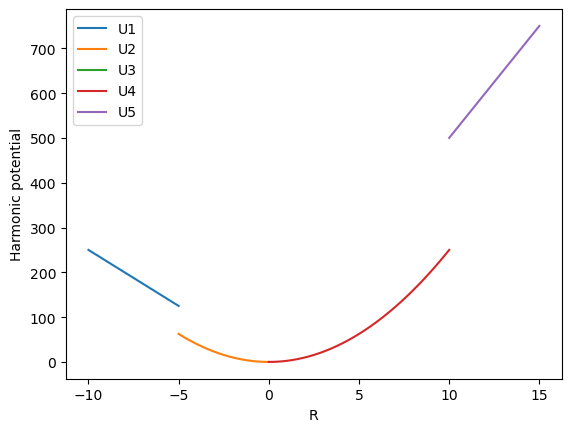

In [17]:
# Define the variables
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2 = 0.0
r3 = r2

# Define the domains
R1 = np.linspace(-10, r1, 100)
R2 = np.linspace(r1, r2, 100)
R3 = np.linspace(r2, r3, 100)
R4 = np.linspace(r3, r4, 100)
R5 = np.linspace(r4, 15, 100)

# Define the functions
U1 = k1 * (r1 - r2) * R1 
U2 = 0.5 * k1 * (R2 - r2)**2
U3 = np.zeros_like(R3)
U4 = 0.5 * k2 * (R4 - r3)**2
U5 = k2 * (r4 - r3) * R5 

# Plot the functions
plt.plot(R1, U1, label='U1')
plt.plot(R2, U2, label='U2')
plt.plot(R3, U3, label='U3')
plt.plot(R4, U4, label='U4')
plt.plot(R5, U5, label='U5')

# Add a legend
plt.legend()
plt.xlabel("R")
plt.ylabel("Harmonic potential")
plt.legend(loc='best')

# Show the plot
plt.show()

i.e., why is the potential well NOT "continuous"?!

##### (WRONG) My random subtraction of the adjacent potential function
i.e., squared subtraction of terms

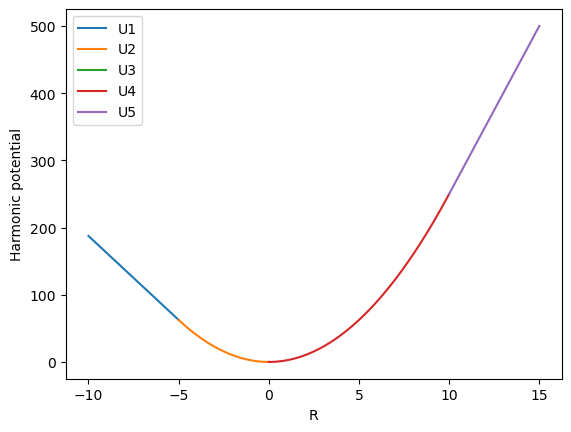

In [25]:
# Define the variables
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2 = 0.0
r3 = r2

# Define the domains
R1 = np.linspace(-10, r1, 100)
R2 = np.linspace(r1, r2, 100)
R3 = np.linspace(r2, r3, 100)
R4 = np.linspace(r3, r4, 100)
R5 = np.linspace(r4, 15, 100)

# Define the functions
U1 = k1 * (r1 - r2) * R1 - (0.5 * k1 * (r1 - r2)**2)
U2 = 0.5 * k1 * (R2 - r2)**2
U3 = np.zeros_like(R3)
U4 = 0.5 * k2 * (R4 - r3)**2
U5 = k2 * (r4 - r3) * R5 - (0.5 * k2 * (r4 - r3)**2)

# Plot the functions
plt.plot(R1, U1, label='U1')
plt.plot(R2, U2, label='U2')
plt.plot(R3, U3, label='U3')
plt.plot(R4, U4, label='U4')
plt.plot(R5, U5, label='U5')

# Add a legend
plt.legend()
plt.xlabel("R")
plt.ylabel("Harmonic potential")
plt.legend(loc='best')

# Show the plot
plt.show()

##### Derivation (Christian & Ibrahim)
i.e., subtraction of squared terms\
based on difference of $U1$ and $U2$ (also for $U4$ and $U5$) at the same $R$

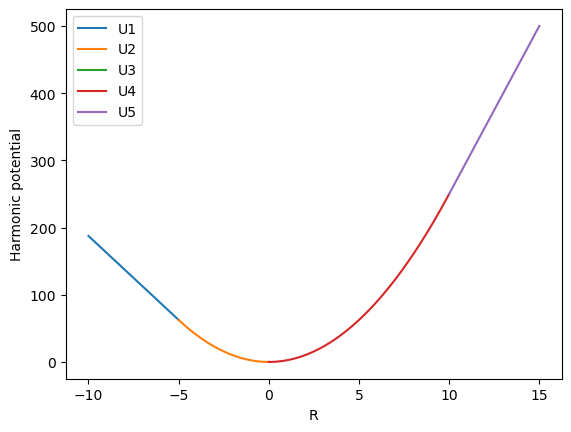

In [20]:
# Define the variables
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2 = 0.0
r3 = r2

# Define the domains
R1 = np.linspace(-10, r1, 100)
R2 = np.linspace(r1, r2, 100)
R3 = np.linspace(r2, r3, 100)
R4 = np.linspace(r3, r4, 100)
R5 = np.linspace(r4, 15, 100)

# Define the functions
U1 = k1 * (r1 - r2) * R1 - 0.5 * k1 * (r1**2 - r2**2)
U2 = 0.5 * k1 * (R2 - r2)**2
U3 = np.zeros_like(R3)
U4 = 0.5 * k2 * (R4 - r3)**2
U5 = k2 * (r4 - r3) * R5 - 0.5 * k2 * (r4**2 - r3**2)

# Plot the functions
plt.plot(R1, U1, label='U1')
plt.plot(R2, U2, label='U2')
plt.plot(R3, U3, label='U3')
plt.plot(R4, U4, label='U4')
plt.plot(R5, U5, label='U5')

# Add a legend
plt.legend()
plt.xlabel("R")
plt.ylabel("Harmonic potential")
plt.legend(loc='best')

# Show the plot
plt.show()

Likely by chance that my random approach (above section) is "correct"!\
Change `r2` value to see which is correct

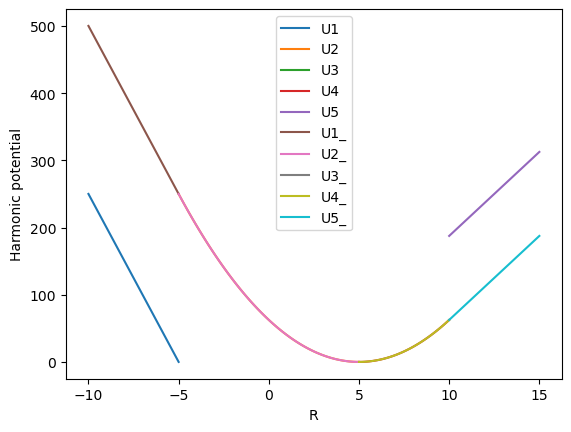

In [27]:
# Define the variables
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2 = 5.0
r3 = r2

# Define the domains
R1 = np.linspace(-10, r1, 100)
R2 = np.linspace(r1, r2, 100)
R3 = np.linspace(r2, r3, 100)
R4 = np.linspace(r3, r4, 100)
R5 = np.linspace(r4, 15, 100)

# Define the functions
U1 = k1 * (r1 - r2) * R1 - (0.5 * k1 * (r1 - r2)**2)
U2 = 0.5 * k1 * (R2 - r2)**2
U3 = np.zeros_like(R3)
U4 = 0.5 * k2 * (R4 - r3)**2
U5 = k2 * (r4 - r3) * R5 - (0.5 * k2 * (r4 - r3)**2)

# Plot the functions
plt.plot(R1, U1, label='U1')
plt.plot(R2, U2, label='U2')
plt.plot(R3, U3, label='U3')
plt.plot(R4, U4, label='U4')
plt.plot(R5, U5, label='U5')

# Define the functions
U1_ = k1 * (r1 - r2) * R1 - 0.5 * k1 * (r1**2 - r2**2)
U2_ = 0.5 * k1 * (R2 - r2)**2
U3_ = np.zeros_like(R3)
U4_ = 0.5 * k2 * (R4 - r3)**2
U5_ = k2 * (r4 - r3) * R5 - 0.5 * k2 * (r4**2 - r3**2)

# Plot the functions
plt.plot(R1, U1_, label='U1_')
plt.plot(R2, U2_, label='U2_')
plt.plot(R3, U3_, label='U3_')
plt.plot(R4, U4_, label='U4_')
plt.plot(R5, U5_, label='U5_')

# Add a legend
plt.legend()
plt.xlabel("R")
plt.ylabel("Harmonic potential")
plt.legend(loc='best')

# Show the plot
plt.show()

i.e., proper derivation is correct

##### Overlay potential wells for all values of `r2` used

(FAIL) Trial 1

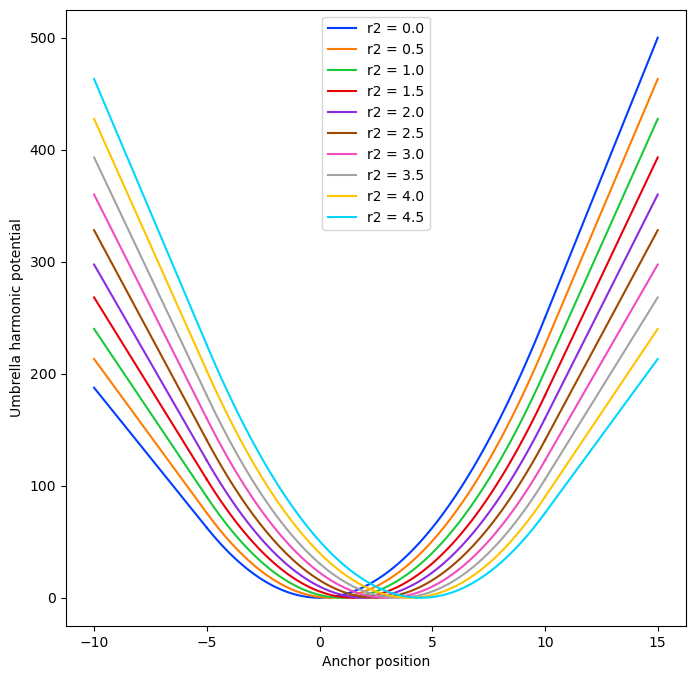

In [29]:
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2_values = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
r3 = 0.0

colors = sns.color_palette("bright", len(r2_values))

plt.figure(figsize=(8, 8))

for i, r2 in enumerate(r2_values):
    r3 = r2

    R1 = np.linspace(-10, r1, 100)
    R2 = np.linspace(r1, r2, 100)
    R3 = np.linspace(r2, r3, 100)
    R4 = np.linspace(r3, r4, 100)
    R5 = np.linspace(r4, 15, 100)

    U1 = k1 * (r1 - r2) * R1 - 0.5 * k1 * (r1**2 - r2**2)
    U2 = 0.5 * k1 * (R2 - r2)**2
    U3 = np.zeros_like(R3)
    U4 = 0.5 * k2 * (R4 - r3)**2
    U5 = k2 * (r4 - r3) * R5 - 0.5 * k2 * (r4**2 - r3**2)

    # Plot the functions with different colors and labels
    plt.plot(R1, U1, color=colors[i], label=f'r2 = {r2}')
    plt.plot(R2, U2, color=colors[i])
    plt.plot(R3, U3, color=colors[i])
    plt.plot(R4, U4, color=colors[i])
    plt.plot(R5, U5, color=colors[i])

plt.xlabel("Anchor position")
plt.ylabel("Umbrella harmonic potential")

# Display the legend
plt.legend()

# Save the figure
plt.savefig("anchor_umbrella_potential_fixed.png", format='png', dpi=300)

plt.show()

(FAIL) Trial 2

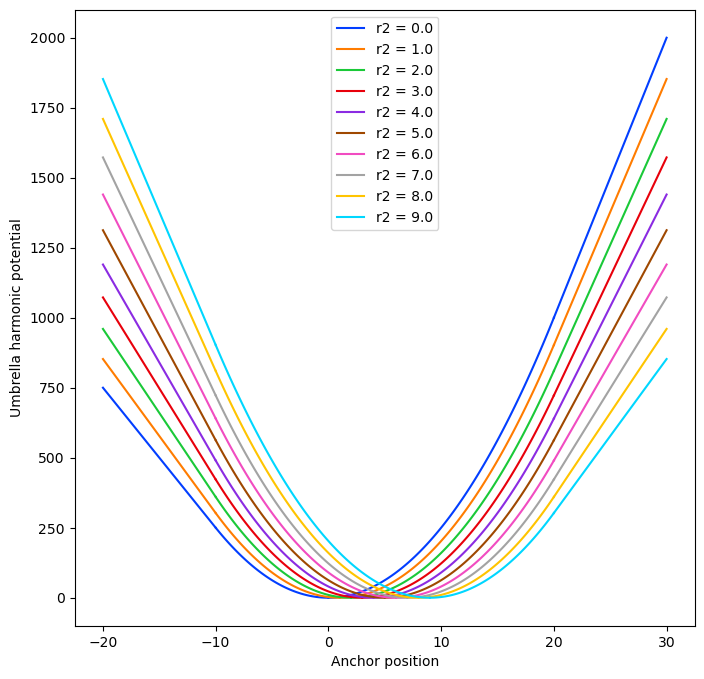

In [28]:
k1, k2 = 5.0, 5.0
r1, r4 = -10.0, 20.0
r2_values = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
r3 = 0.0

colors = sns.color_palette("bright", len(r2_values))

plt.figure(figsize=(8, 8))

for i, r2 in enumerate(r2_values):
    r3 = r2

    R1 = np.linspace(-20, r1, 100)
    R2 = np.linspace(r1, r2, 100)
    R3 = np.linspace(r2, r3, 100)
    R4 = np.linspace(r3, r4, 100)
    R5 = np.linspace(r4, 30, 100)

    U1 = k1 * (r1 - r2) * R1 - 0.5 * k1 * (r1**2 - r2**2)
    U2 = 0.5 * k1 * (R2 - r2)**2
    U3 = np.zeros_like(R3)
    U4 = 0.5 * k2 * (R4 - r3)**2
    U5 = k2 * (r4 - r3) * R5 - 0.5 * k2 * (r4**2 - r3**2)

    # Plot the functions with different colors and labels
    plt.plot(R1, U1, color=colors[i], label=f'r2 = {r2}')
    plt.plot(R2, U2, color=colors[i])
    plt.plot(R3, U3, color=colors[i])
    plt.plot(R4, U4, color=colors[i])
    plt.plot(R5, U5, color=colors[i])

plt.xlabel("Anchor position")
plt.ylabel("Umbrella harmonic potential")

# Display the legend
plt.legend()

# Save the figure
plt.savefig("anchor_umbrella_potential_fixed.png", format='png', dpi=300)

plt.show()

TRIAL 3

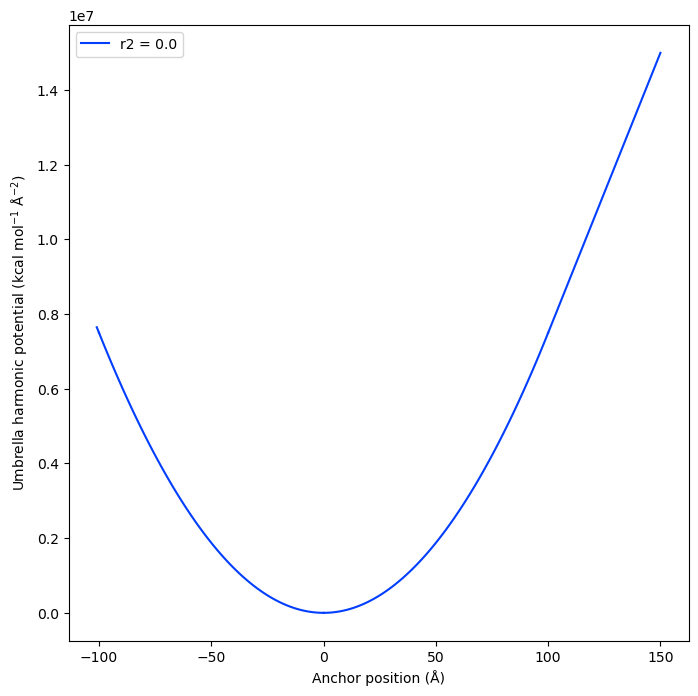

In [58]:
k1 = 1500.0
k2 = k1
r1, r4 = -100, 100
r2_values = [0.0] #[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
r3 = 0.0

colors = sns.color_palette("bright", len(r2_values))

plt.figure(figsize=(8, 8))

for i, r2 in enumerate(r2_values):
    r3 = r2

    R1 = np.linspace(r1-1, r1, 100)
    R2 = np.linspace(r1, r2, 100)
    R3 = np.linspace(r2, r3, 100)
    R4 = np.linspace(r3, r4, 100)
    R5 = np.linspace(r4, r4+50, 100)

    U1 = k1 * (r1 - r2) * R1 - 0.5 * k1 * (r1**2 - r2**2)
    U2 = 0.5 * k1 * (R2 - r2)**2
    U3 = np.zeros_like(R3)
    U4 = 0.5 * k2 * (R4 - r3)**2
    U5 = k2 * (r4 - r3) * R5 - 0.5 * k2 * (r4**2 - r3**2)

    # Plot the functions with different colors and labels
    plt.plot(R1, U1, color=colors[i], label=f'r2 = {r2}')
    plt.plot(R2, U2, color=colors[i])
    plt.plot(R3, U3, color=colors[i])
    plt.plot(R4, U4, color=colors[i])
    plt.plot(R5, U5, color=colors[i])

plt.xlabel("Anchor position (Å)")
plt.ylabel("Umbrella harmonic potential (kcal mol$^{-1}$ Å$^{-2}$)")

# Display the legend
plt.legend()

# Save the figure
plt.savefig("anchor_umbrella_potential_fixed.png", format='png', dpi=300)

plt.show()

(HOW?) Overlay other `anchor_strength`s

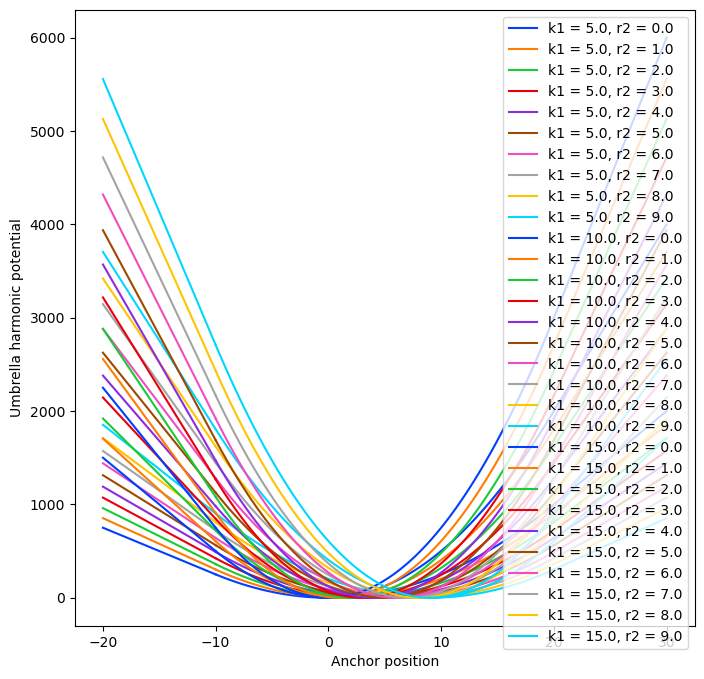

In [40]:
k1_values = [5.0, 10.0, 15.0]  # Add more values as needed
r1 = -10.0
r2_values = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
r4 = 20.0

colors = sns.color_palette("bright", len(r2_values) * len(k1_values))

plt.figure(figsize=(8, 8))

# initialize variables to be assigned in the for loop
k2 = 0.0
r3 = 0.0
color_index = 0
for k1 in k1_values:
    k2 = k1
    for i, r2 in enumerate(r2_values):
        r3 = r2

        R1 = np.linspace(-20, r1, 100)
        R2 = np.linspace(r1, r2, 100)
        R3 = np.linspace(r2, r3, 100)
        R4 = np.linspace(r3, r4, 100)
        R5 = np.linspace(r4, 30, 100)

        U1 = k1 * (r1 - r2) * R1 - 0.5 * k1 * (r1**2 - r2**2)
        U2 = 0.5 * k1 * (R2 - r2)**2
        U3 = np.zeros_like(R3)
        U4 = 0.5 * k2 * (R4 - r3)**2
        U5 = k2 * (r4 - r3) * R5 - 0.5 * k2 * (r4**2 - r3**2)

        # Plot the functions with different colors and labels
        plt.plot(R1, U1, color=colors[color_index], label=f'k1 = {k1}, r2 = {r2}')
        plt.plot(R2, U2, color=colors[color_index])
        plt.plot(R3, U3, color=colors[color_index])
        plt.plot(R4, U4, color=colors[color_index])
        plt.plot(R5, U5, color=colors[color_index])

        color_index += 1

plt.xlabel("Anchor position")
plt.ylabel("Umbrella harmonic potential")

# Display the legend
plt.legend()

# Save the figure
plt.savefig("anchor_umbrella_potential_fixed.png", format='png', dpi=300)

plt.show()

Perhaps:
1. `r2` should be more spread out? Especially when the RMSD is low (conformation space is smaller than when it is large)
2. `r1` and `r4` should be larger (magnitude)? To make the potential well "gentler"

##### WRONG plots

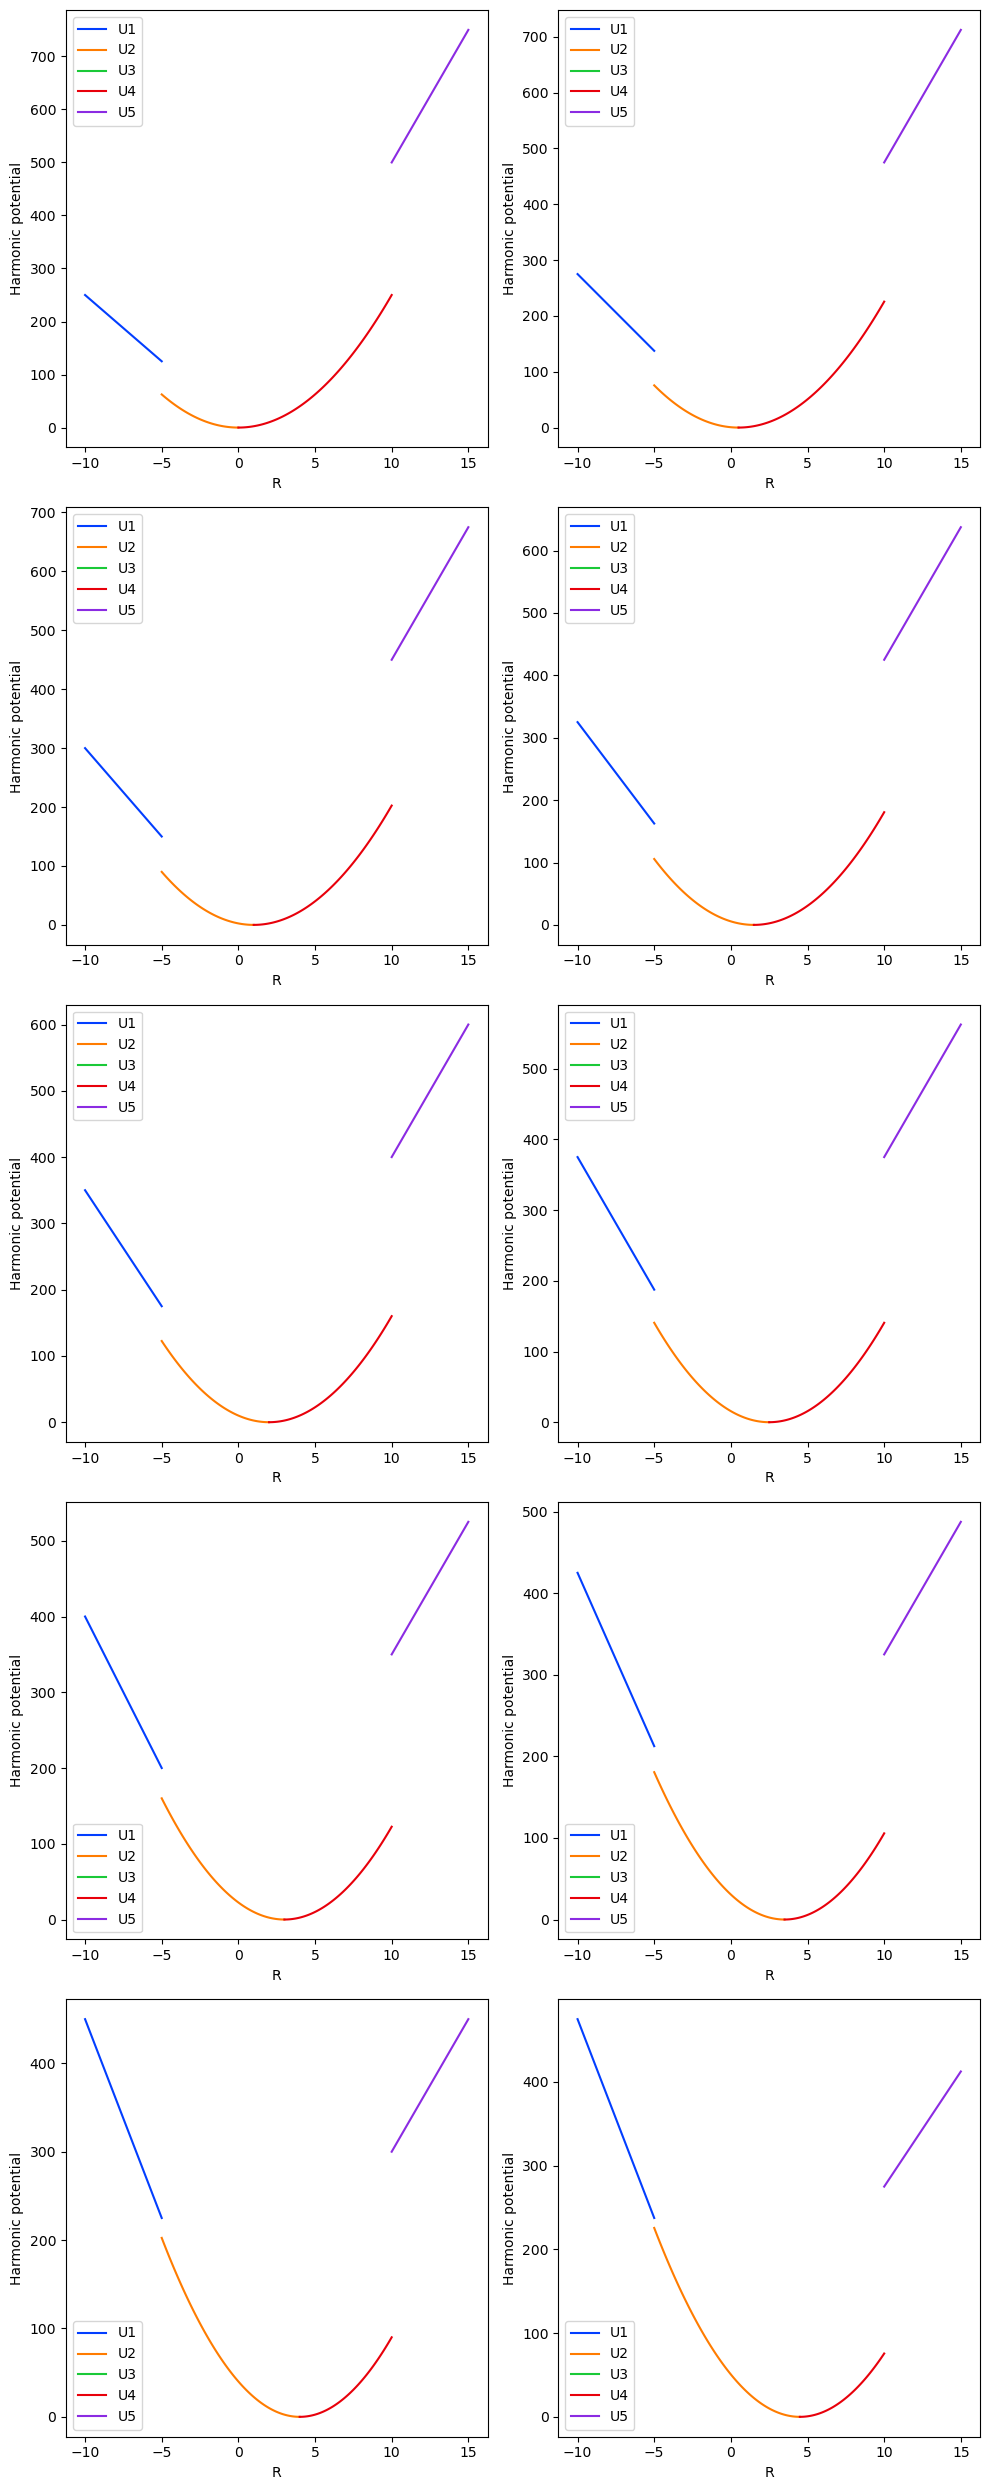

In [38]:
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2_values = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
r3 = 0.0

fig, axs = plt.subplots(5, 2, figsize=(10, 25))  # Adjusted to 5 rows and 2 columns

for i, r2 in enumerate(r2_values):
    r3 = r2

    R1 = np.linspace(-10, r1, 100)
    R2 = np.linspace(r1, r2, 100)
    R3 = np.linspace(r2, r3, 100)
    R4 = np.linspace(r3, r4, 100)
    R5 = np.linspace(r4, 15, 100)

    U1 = k1 * (r1 - r2) * R1
    U2 = 0.5 * k1 * (R2 - r2)**2
    U3 = np.zeros_like(R3)
    U4 = 0.5 * k2 * (R4 - r3)**2
    U5 = k2 * (r4 - r3) * R5

    ax = axs[i // 2, i % 2]  # Adjusted to select the correct subplot
    ax.plot(R1, U1, label='U1')
    ax.plot(R2, U2, label='U2')
    ax.plot(R3, U3, label='U3')
    ax.plot(R4, U4, label='U4')
    ax.plot(R5, U5, label='U5')

    ax.legend()
    ax.set_xlabel("R")
    ax.set_ylabel("Harmonic potential")
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

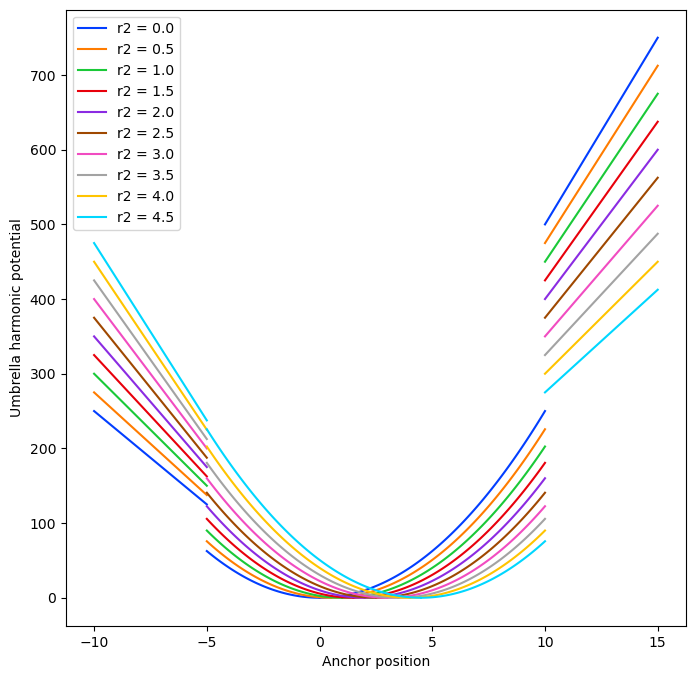

In [30]:
k1, k2 = 5.0, 5.0
r1, r4 = -5.0, 10.0
r2_values = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
r3 = 0.0

colors = sns.color_palette("bright", len(r2_values))

plt.figure(figsize=(8, 8))

for i, r2 in enumerate(r2_values):
    r3 = r2

    R1 = np.linspace(-10, r1, 100)
    R2 = np.linspace(r1, r2, 100)
    R3 = np.linspace(r2, r3, 100)
    R4 = np.linspace(r3, r4, 100)
    R5 = np.linspace(r4, 15, 100)

    U1 = k1 * (r1 - r2) * R1
    U2 = 0.5 * k1 * (R2 - r2)**2
    U3 = np.zeros_like(R3)
    U4 = 0.5 * k2 * (R4 - r3)**2
    U5 = k2 * (r4 - r3) * R5

    # Plot the functions with different colors and labels
    plt.plot(R1, U1, color=colors[i], label=f'r2 = {r2}')
    plt.plot(R2, U2, color=colors[i])
    plt.plot(R3, U3, color=colors[i])
    plt.plot(R4, U4, color=colors[i])
    plt.plot(R5, U5, color=colors[i])

plt.xlabel("Anchor position")
plt.ylabel("Umbrella harmonic potential")

# Display the legend
plt.legend()

# Save the figure
plt.savefig("anchor_umbrella_potential_legend.png", format='png', dpi=300)

plt.show()

#### (WRONG) Non-equilibrated interface atom coordinates

`colv0.in`
```in
&colvar
    cv_type = 'MULTI_RMSD'
    cv_ni = 84, cv_nr = 252,
    cv_i = 870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746, 4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688
    cv_r = 4.257, -2.851, -2.134, 1.645, -1.376, -1.816, 0.079, -8.641, -7.187, 1.29, -9.189, -6.429, 0.093, -9.876, -4.425, -0.218, -10.689, -3.373, -1.01, -10.226, -2.362, -5.635, -11.299, -10.064, -5.861, -10.445, -8.804, -5.598, -8.952, -8.974, -5.467, -8.241, -7.627, -4.286, -8.834, -6.935, -4.008, -8.51, -5.639, -4.809, -7.631, -4.968, -2.93, -9.065, -5.012, -8.428, -7.884, -14.385, -9.531, -7.433, -13.428, -11.075, -13.437, -12.492, -11.405, -12.009, -12.034, -10.936, -11.806, -10.709, -11.506, -13.389, -16.246, -14.684, -17.606, -11.543, -15.781, -14.638, -16.131, 5.031, -4.705, 5.38, 1.678, -10.678, 1.396, 0.636, -10.963, 0.561, 2.326, -9.481, 1.292, -1.985, -6.088, 5.923, 2.813, -6.456, 5.367, 1.046, -7.304, 4.219, -2.71, -10.768, 4.884, -3.138, -11.186, 3.465, -3.253, -9.402, 5.336, -3.286, -12.53, 0.624, -2.312, 4.24, 4.498, 0.133, -0.58, 7.602, -7.839, 2.401, 8.786, -9.179, 2.361, 8.05, -10.299, 2.454, 9.078, -10.381, 3.609, 9.791, -5.354, -0.794, 5.396, -4.108, -1.014, 4.524, -10.513, -2.548, 6.342, -10.092, -0.261, 5.78, -7.813, -6.171, 5.403, -9.263, -11.387, 5.999, -9.323, 5.283, 5.336, -10.076, 4.728, 6.542, -4.489, 6.156, 2.531, -9.099, 1.189, 2.532, -11.706, 0.224, 2.777, -0.487, 3.574, 1.205, -1.004, 4.839, 1.039, -2.629, -5.42, -3.677, -0.701, -7.065, -3.81, -7.086, -4.966, -7.409, -7.839, -5.899, -8.371, -5.607, -5.329, -7.198, -11.253, -5.03, -11.146, -11.691, -7.357, -15.441, -13.946, -11.131, -13.224, -14.1, -11.955, -14.5, -16.579, -14.915, -9.421, -17.506, -15.475, -10.068, -15.978, -15.446, -8.45, -8.519, -11.149, -7.463, -8.217, -7.632, -4.489, -8.486, -6.528, -4.018, -7.676, -7.785, -5.728, -7.695, -10.685, 3.058, -5.63, -5.363, 2.626, -6.06, -4.094, 3.383, -7.312, -3.565, 2.771, -8.542, -4.014, 3.191, -9.696, -3.522, 2.629, -1.878, -5.788, 2.737, -1.185, -6.863, 1.881, -1.9, -8.189, 2.085, -2.866, -8.214, 2.893, -1.499, -9.19, 1.432, 1.025, -2.326, 4.196, 1.626, -3.21, 5.301, 1.882, -0.036, 4.964, 2.524, -3.214, 1.317
    anchor_position = -5.0, 0.0, 0.0, 10.0
    anchor_strength = 5.0, 5.0
/

```

## Production with FSC

##### (WRONG) NOT enough input flags

`prod_colv_gpu1.sh`
```sh
#!/bin/bash
#SBATCH --job-name=trial9_param_FSC_colv
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --gres=gpu:1
#SBATCH --mem=4G
#SBATCH --constraint='rtx2080ti|rtxa5000|rtx4090'
#SBATCH --exclude=t38cn031,t38cn027,t38cn032
#SBATCH --time=3-00:00:00

#Use own amber version for pulling sim
module load cuda/11.8.0
module load amber/20.13/21.12

export AMBERHOME=/apps/amber/20.13-tools-21.12
export CUDA_VISIBLE_DEVICES=0

cd /zfs/s01/z03/home/studenT38/wonjoon/9dot1_colv

# Print CUDA device information
echo "CUDA device information:"
nvidia-smi
nvidia-smi --query-gpu=name --format=csv

echo "starting colv0 at $(date)"
pmemd.cuda -O -i mdr0.in -c amber_o98_FSC_cubic_ion.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv0.rst7 -o colv0.out -x colv0.nc
echo "finished colv0 at $(date)"

echo "starting colv1 at $(date)"
pmemd.cuda -O -i mdr1.in -c colv0.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv1.rst7 -o colv1.out -x colv1.nc
echo "finished colv1 at $(date)"

echo "starting colv2 at $(date)"
pmemd.cuda -O -i mdr2.in -c colv1.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv2.rst7 -o colv2.out -x colv2.nc
echo "finished colv2 at $(date)"

echo "starting colv3 at $(date)"
pmemd.cuda -O -i mdr3.in -c colv2.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv3.rst7 -o colv3.out -x colv3.nc
echo "finished colv3 at $(date)"

echo "starting colv4 at $(date)"
pmemd.cuda -O -i mdr4.in -c colv3.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv4.rst7 -o colv4.out -x colv4.nc
echo "finished colv4 at $(date)"

echo "starting colv5 at $(date)"
pmemd.cuda -O -i mdr5.in -c colv4.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv5.rst7 -o colv5.out -x colv5.nc
echo "finished colv5 at $(date)"

echo "starting colv6 at $(date)"
pmemd.cuda -O -i mdr6.in -c colv5.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv6.rst7 -o colv6.out -x colv6.nc
echo "finished colv6 at $(date)"

echo "starting colv7 at $(date)"
pmemd.cuda -O -i mdr7.in -c colv6.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv7.rst7 -o colv7.out -x colv7.nc
echo "finished colv7 at $(date)"

echo "starting colv8 at $(date)"
pmemd.cuda -O -i mdr8.in -c colv7.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv8.rst7 -o colv8.out -x colv8.nc
echo "finished colv8 at $(date)"

echo "starting colv9 at $(date)"
pmemd.cuda -O -i mdr9.in -c colv8.rst7 -p amber_o98_FSC_cubic_ion.parm7 -r colv9.rst7 -o colv9.out -x colv9.nc
echo "finished colv9 at $(date)"
```
NOTE:\
Use the previous window's RESTART (`rst7`) file to preserve altered trajectory\
i.e., gradual increase in harmonic potential\
instead of directly applying large harmonic potential to "ground" state 

##### (revised but WRONG) still NOT enough input flags

`prod_2o98_FSC_colv.sh`
```sh
#!/bin/bash
#SBATCH --job-name=prod_2o98_FSC_colv
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --gres=gpu:1
#SBATCH --constraint='rtx2080ti|rtxa5000|rtx4090'
#SBATCH --exclude=t38cn031,t38cn027,t38cn032
#SBATCH --time=3-00:00:00

#Use own amber version for pulling sim
module load cuda/11.8.0
module load amber/20.13/21.12

export AMBERHOME=/apps/amber/20.13-tools-21.12
export CUDA_VISIBLE_DEVICES=0

cd /zfs/s01/z03/home/studenT38/wonjoon/9dot1_colv_redo1

# Print CUDA device information
echo "CUDA device information:"
nvidia-smi
nvidia-smi --query-gpu=name --format=csv

echo "starting colv0 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr0.in -o colv0.out -p amber_o98_FSC_cubic_ion.parm7 -c 9md.rst7 -r colv0.rst7 -x colv0.nc
echo "finished colv0 at $(date)"

echo "starting colv1 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr1.in -o colv1.out -p amber_o98_FSC_cubic_ion.parm7 -c colv0.rst7 -r colv1.rst7 -x colv1.nc
echo "finished colv1 at $(date)"

echo "starting colv2 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr2.in -o colv2.out -p amber_o98_FSC_cubic_ion.parm7 -c colv1.rst7 -r colv2.rst7 -x colv2.nc
echo "finished colv2 at $(date)"

echo "starting colv3 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr3.in -o colv3.out -p amber_o98_FSC_cubic_ion.parm7 -c colv2.rst7 -r colv3.rst7 -x colv3.nc
echo "finished colv3 at $(date)"

echo "starting colv4 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr4.in -o colv4.out -p amber_o98_FSC_cubic_ion.parm7 -c colv3.rst7 -r colv4.rst7 -x colv4.nc
echo "finished colv4 at $(date)"

echo "starting colv5 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr5.in -o colv5.out -p amber_o98_FSC_cubic_ion.parm7 -c colv4.rst7 -r colv5.rst7 -x colv5.nc
echo "finished colv5 at $(date)"

echo "starting colv6 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr6.in -o colv6.out -p amber_o98_FSC_cubic_ion.parm7 -c colv5.rst7 -r colv6.rst7 -x colv6.nc
echo "finished colv6 at $(date)"

echo "starting colv7 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr7.in -o colv7.out -p amber_o98_FSC_cubic_ion.parm7 -c colv6.rst7 -r colv7.rst7 -x colv7.nc
echo "finished colv7 at $(date)"

echo "starting colv8 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr8.in -o colv8.out -p amber_o98_FSC_cubic_ion.parm7 -c colv7.rst7 -r colv8.rst7 -x colv8.nc
echo "finished colv8 at $(date)"

echo "starting colv9 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr9.in -o colv9.out -p amber_o98_FSC_cubic_ion.parm7 -c colv8.rst7 -r colv9.rst7 -x colv9.nc
echo "finished colv9 at $(date)"
```
1. use `9md.rst7` i.e., RESTART file (with velocities) from the end of the equilibration step\
    using `amber_o98_FSC_cubic_ion.rst7` gives:
    ```out
    | ERROR:   I could not find enough velocities in amber_o98_FSC_cubic_ion.rst7 
    ```

### System completely DISINTEGRATES from first production?
1. Is the `anchor_strength` NOT strong enough to keep RMSD at the desired 0.0 Å?
2. Are there PROBLEMS in the `MULTI_RMSD` code?
3. Are `r1` and `r4` too close to `r2`? (i.e., well too "narrow")

### Test system disintegration only for `colv0.in`
i.e., restrain at 0.0 Å (`r2=0.0`)

#### 1. (FAIL) interface atoms `k=100.0`

#### 2. (FAIL) interface atoms `k=1000.0`

#### 3. (FAIL) interface atoms `k=1500.0`
`B2/trial9_param_FSC_terminal_finished/9dot8_colv0_int_atom_str1500/`\
Job cancelled before completion although RMSD $\approx$ 0.5 Å $\because$ intermediate `.nc` disintegration observed

Frame 14\
![int_atom_str1500_frame14](B2/trial9_param_FSC_terminal_finished/9dot8_colv0_int_atom_str1500/tachyon_int_atom_str1500_frame14.png)
1. alpha helices are elongated and unwinding?!

NOTE: FSC looks like it escaped from the complex $\because$ periodic image shown\
i.e., FSC traversed beyond solvent box boundary\
(observable with "water" representation ON)

Frame 56 (recorded right before cancellation)\
![int_atom_str1500_frame56](B2/trial9_param_FSC_terminal_finished/9dot8_colv0_int_atom_str1500/tachyon_int_atom_str1500_frame56.png)
1. complete disintegration...

#### 4. (REJECT?) whole complex atoms `k=1500` 
`B2/trial9_param_FSC_terminal_finished/9dot9_colv0_all_atom/`

does restraining ligand protein make sense? 
1. NOT close to reality 
2. interested in allosteric regulation of stabilizer on "receptor" ONLY 

Frame 500 (last)\
![frame500](B2/trial9_param_FSC_terminal_finished/9dot9_colv0_all_atom/frame500.png)

,MD time (ps),Collective variable (1:1)
0,4000.0,2.830183
1,4001.0,1.430672
2,4002.0,1.335400
3,4003.0,1.277446
4,4004.0,1.224968
...,...,...
9995,13995.0,0.708291
9996,13996.0,0.729420
9997,13997.0,0.716751
9998,13998.0,0.725130


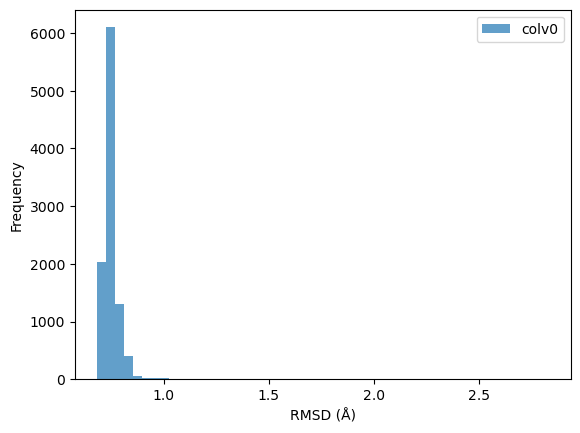

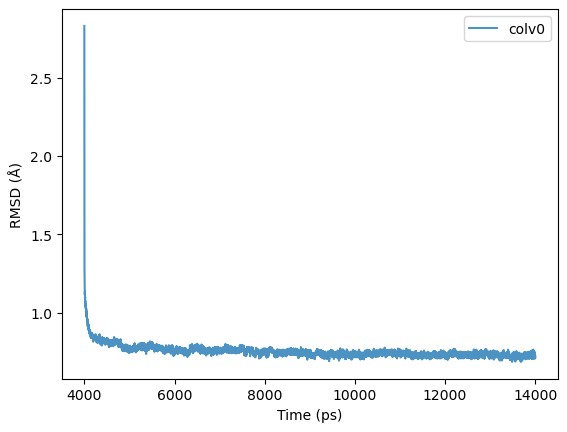

In [86]:
colv0_FSC_allAtom_k1500_path = 'B2/trial9_param_FSC_terminal_finished/9dot9_colv0_all_atom/colv0.dat'
column_names = ["MD time (ps)", "Collective variable (1:1)"]
colv0_FSC_allAtom_k1500_df = pd.read_csv(colv0_FSC_allAtom_k1500_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_FSC_allAtom_k1500_df)

sns.histplot(colv0_FSC_allAtom_k1500_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv0', edgecolor='none')
plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')
plt.show()

sns.lineplot(data=colv0_FSC_allAtom_k1500_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv0', alpha=0.8)
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')
plt.show()

#### 5. (FAIL... but useful?) interface residue atoms `k=1500`
`B2/trial9_param_FSC_terminal_finished/9dot10_colv0_all_int_residue/`

Frame 61\
![frame61](B2/trial9_param_FSC_terminal_finished/9dot10_colv0_all_int_residue/frame61.png)
1. ATPase unfolded to keep interface residues at the initial coordinates?!

Frame 500 (last)\
NOTE: solvent box (VDW, Glass1, Opacity 0.02) shown to justify periodic images being shown during trajectory\
![frame434](B2/trial9_param_FSC_terminal_finished/9dot10_colv0_all_int_residue/frame434.png)
1. ATPase still unfolded...
2. BUT 14-3-3 is somehow rigid throughout?!\
$\rightarrow$ try simulating only interface residues on 14-3-3?\
NOTE: stabilizer only affecting receptor interface rigidity is desired

#### 6. (REJECT?) _constant volume_ interface atoms `k=1500`
`B2/trial9_param_FSC_terminal_finished/9dot11_colv0_int_atom_nvt`

constant volume is NOT very representative of biological system...?\
BUT Christian says is beneficial to "replica exchange" method\
which is independent of umbrella sampling...

Frame 500 (last)\
![frame500](B2/trial9_param_FSC_terminal_finished/9dot11_colv0_int_atom_nvt/frame500.png)
1. NO disintegration! $\rightarrow$ is constant volume a better simulation? Just like Prof's input?

,MD time (ps),Collective variable (1:1)
0,4000.0,2.051757
1,4001.0,0.379822
2,4002.0,0.342505
3,4003.0,0.340800
4,4004.0,0.357526
...,...,...
9995,13995.0,0.294625
9996,13996.0,0.306556
9997,13997.0,0.299188
9998,13998.0,0.285658


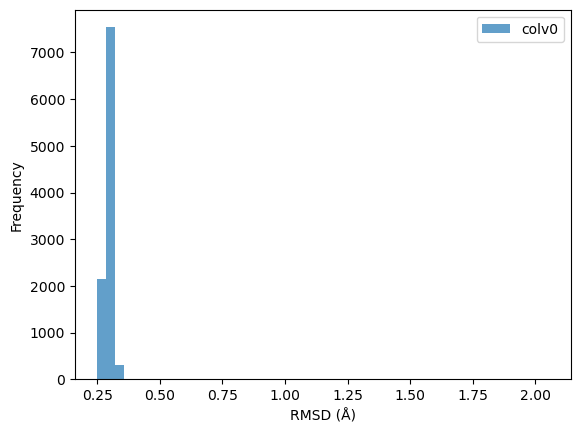

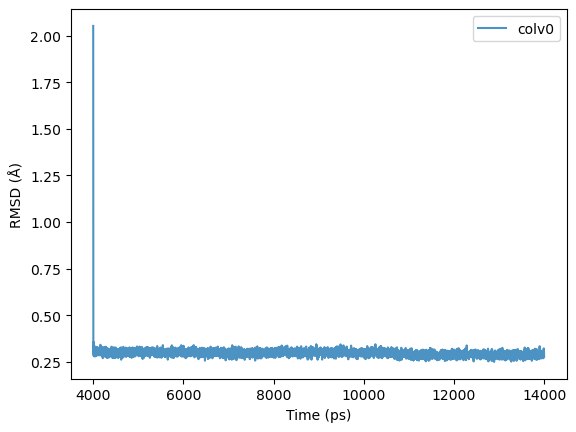

In [87]:
colv0_FSC_intAtom_NVT_k1500_path = 'B2/trial9_param_FSC_terminal_finished/9dot11_colv0_int_atom_nvt/colv0.dat'
column_names = ["MD time (ps)", "Collective variable (1:1)"]
colv0_FSC_intAtom_NVT_k1500_df = pd.read_csv(colv0_FSC_intAtom_NVT_k1500_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_FSC_intAtom_NVT_k1500_df)

sns.histplot(colv0_FSC_intAtom_NVT_k1500_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv0', edgecolor='none')
plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')
plt.show()

sns.lineplot(data=colv0_FSC_intAtom_NVT_k1500_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv0', alpha=0.8)
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')
plt.show()

#### 7. whole receptor atoms `k=1500`
`B2/trial9_param_FSC_terminal_finished/9dot12_colv0_all_receptor_atom`

most DESIRABLE simulation?
1. NPT
2. complex NOT disintegrated
3. RMSD $\approx$ 0.5 Å
4. TEMP $\approx$ 312 K

too large harmonic constant?

Frame 500 (last)\
![frame500](B2/trial9_param_FSC_terminal_finished/9dot12_colv0_all_receptor_atom/frame500.png)

,MD time (ps),Collective variable (1:1)
0,4000.0,2.046242
1,4001.0,1.294221
2,4002.0,1.219225
3,4003.0,1.189525
4,4004.0,1.159521
...,...,...
9995,13995.0,0.659331
9996,13996.0,0.660032
9997,13997.0,0.665272
9998,13998.0,0.659284


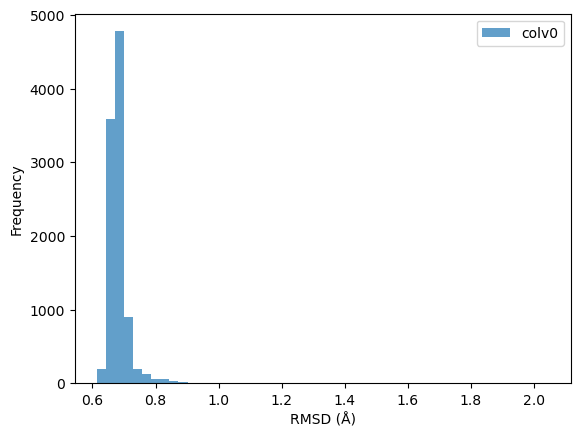

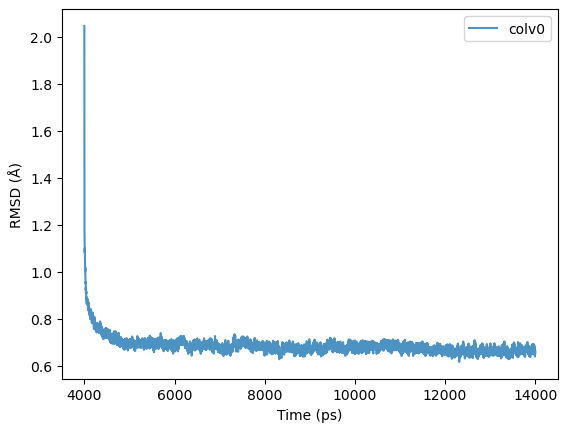

In [88]:
colv0_FSC_recepAtom_k1500_path = 'B2/trial9_param_FSC_terminal_finished/9dot12_colv0_all_receptor_atom/colv0.dat'
column_names = ["MD time (ps)", "Collective variable (1:1)"]
colv0_FSC_recepAtom_k1500_df = pd.read_csv(colv0_FSC_recepAtom_k1500_path, comment='#', delim_whitespace=True, header=None, names=column_names)
display(colv0_FSC_recepAtom_k1500_df)

sns.histplot(colv0_FSC_recepAtom_k1500_df["Collective variable (1:1)"], bins=50, alpha=0.7, label='colv0', edgecolor='none')
plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')
plt.show()

sns.lineplot(data=colv0_FSC_recepAtom_k1500_df, x="MD time (ps)", y="Collective variable (1:1)", label='colv0', alpha=0.8)
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')
plt.show()

### Try for all 10 `colv_.in` (in order of most likely to be "correct"):
1. receptor interface residues
2. ~~receptor interface atoms~~ (NOT good prospects after above FAILed)
3. receptor atoms

with `k=10, 100, 500, 1000, 1500`\
$\because$ `k` $\approx$ `500` is already too high of a harmonic constant ( https://ambermd.org/tutorials/basic/tutorial1/section5.php )\
$\rightarrow$ may NOT be able to capture the most "natural" trajectory?

BUT is it better to be "natural"? Goal is to get the RMSD to be near the specified value... ( http://archive.ambermd.org/201107/0516.html )

#### 1. (FAIL) receptor interface residues 
all 5 systems completely disintegrate

##### (FAIL) `k=10`
RMSD >> 1 Å, but TEMP ≈ 310 K

##### (FAIL) `k=100`
RMSD >> 1 Å, but TEMP $\approx$ 310 K

##### (FAIL) `k=500`
RMSD $\approx$ 1 Å & TEMP $\approx$ 310 K

##### (FAIL) `k=1000`
RMSD $\approx$ 0.5 Å & TEMP $\approx$ 310 K

##### (FAIL) `k=1500`
RMSD $\approx$ 0.5 Å & TEMP $\approx$ 310 K

#### 3. receptor atoms
(NG) Skipped `k=10` $\because$ seemed too low to restrain protein at desired RMSD (above)

##### `k=100`

##### `k=500`

##### `k=1000`

##### `k=1500`

## Production without FSC

`prod_2o98_noFSC_colv.sh`
```sh
#!/bin/bash
#SBATCH --job-name=prod_2o98_noFSC_colv
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --gres=gpu:1
#SBATCH --constraint='rtx2080ti|rtxa5000|rtx4090'
#SBATCH --exclude=t38cn031,t38cn027,t38cn032
#SBATCH --time=3-00:00:00

#Use own amber version for pulling sim
module load cuda/11.8.0
module load amber/20.13/21.12

export AMBERHOME=/apps/amber/20.13-tools-21.12
export CUDA_VISIBLE_DEVICES=0

cd /zfs/s01/z03/home/studenT38/wonjoon/7dot1_colv_redo

# Print CUDA device information
echo "CUDA device information:"
nvidia-smi
nvidia-smi --query-gpu=name --format=csv

echo "starting colv0 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr0.in -c 9md.rst7 -p amber_o98_cubic_ion.parm7 -r colv0.rst7 -o colv0.out -x colv0.nc
echo "finished colv0 at $(date)"

echo "starting colv1 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr1.in -c colv0.rst7 -p amber_o98_cubic_ion.parm7 -r colv1.rst7 -o colv1.out -x colv1.nc
echo "finished colv1 at $(date)"

echo "starting colv2 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr2.in -c colv1.rst7 -p amber_o98_cubic_ion.parm7 -r colv2.rst7 -o colv2.out -x colv2.nc
echo "finished colv2 at $(date)"

echo "starting colv3 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr3.in -c colv2.rst7 -p amber_o98_cubic_ion.parm7 -r colv3.rst7 -o colv3.out -x colv3.nc
echo "finished colv3 at $(date)"

echo "starting colv4 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr4.in -c colv3.rst7 -p amber_o98_cubic_ion.parm7 -r colv4.rst7 -o colv4.out -x colv4.nc
echo "finished colv4 at $(date)"

echo "starting colv5 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr5.in -c colv4.rst7 -p amber_o98_cubic_ion.parm7 -r colv5.rst7 -o colv5.out -x colv5.nc
echo "finished colv5 at $(date)"

echo "starting colv6 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr6.in -c colv5.rst7 -p amber_o98_cubic_ion.parm7 -r colv6.rst7 -o colv6.out -x colv6.nc
echo "finished colv6 at $(date)"

echo "starting colv7 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr7.in -c colv6.rst7 -p amber_o98_cubic_ion.parm7 -r colv7.rst7 -o colv7.out -x colv7.nc
echo "finished colv7 at $(date)"

echo "starting colv8 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr8.in -c colv7.rst7 -p amber_o98_cubic_ion.parm7 -r colv8.rst7 -o colv8.out -x colv8.nc
echo "finished colv8 at $(date)"

echo "starting colv9 at $(date)"
$AMBERHOME/bin/pmemd.cuda -O -i mdr9.in -c colv8.rst7 -p amber_o98_cubic_ion.parm7 -r colv9.rst7 -o colv9.out -x colv9.nc
echo "finished colv9 at $(date)"
```

## Steered Molecular Dynamics?

Instead of running many `colv_.in` sequentially with `&pmd` block in `mdr_.in`,\
use Steered Molecular Dynamics block `&smd` to use a single input command\
to run a continuous simulation where the RMSD will vary with time (every 10 ns)\
which possibly will make it easier for umbrella sampling?\
`example_cv_file.in`
```in
cv_file
&colvar
    cv_type = 'DISTANCE'
    cv_ni = 2
    cv_i = 5, 9
    npath = 2, path = 5.0, 3.0, path_mode = 'LINES',
    nharm = 1, harm = 10.0
/

```
Settings:
1. `cv_type`: change to "`MULTI_RMSD`" for my purpose
2. `npath`: number of elements in `path`
3. `path`: steering path whose elements must be real numbers. The path must include at least two elements. The upper limit on the number of entries is 20000. The elements define Catmull-Rom spline used for steering.\
    a. RMSD values? \
    b. Harmonic potential "well" values (like `anchor_position`)?
4. `path_mode` (and `harm_mode`):\
    a. `SPLINE` (default): path is approximated by a (non-linear?) spline that passes through the given points\
    b. `LINES`: path is represented by the line segments joining the control points
5. `nharm`: number of elements in `harm`
6. `harm`: specifies the harmonic constant ("spring strength"). If a single number is provided, e.g., `harm = 10.0` (kcal/mol/rad<sup>2</sup>), then it is constant throughout the run. If two or more numbers are provided, e.g., `harm = 10.0, 20.0`, then the harmonic constant follows a Catmull-Rom spline built upon the provided values

AMBER22 manual 25.4.3. Steered Molecular Dynamics